# Лабораторная работа 9. Рекуррентные сети и трансформеры: архитектуры для последовательностей и текста

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 7**


**Вариант / seed:** _номер варианта или значение SEED_


### Таблица вариантов

| Вариант | `SEED` | `D_MODEL` | `N_MAX` (пар в обучении) | `D_CELL` | Температуры для части H |
|---|---|---|---|---|---|
| 1 | 42 | 64 | 12 | 48 | 0.5 / 1.0 / 1.5 |
| 2 | 7 | 48 | 10 | 40 | 0.4 / 1.0 / 1.6 |
| 3 | 123 | 64 | 8 | 48 | 0.6 / 1.0 / 1.4 |
| 4 | 2024 | 56 | 12 | 56 | 0.5 / 1.2 / 1.8 |
| 5 | 314 | 48 | 8 | 40 | 0.7 / 1.0 / 1.3 |
| 6 | 555 | 64 | 10 | 56 | 0.5 / 0.9 / 1.7 |

> Вариант выдаёт преподаватель. Все числа в отчёте должны соответствовать **вашему** варианту,
> а не значениям из примера в тексте.

### Цель работы

Экспериментально установить, чем механизм внимания отличается от рекуррентного накопления состояния,
какой ценой достигается каждое из свойств (точность вспоминания, стоимость контекста, память при
генерации), и какие архитектурные свойства становятся поверхностью атаки на языковые модели.

### Задачи

1. Реализовать BPE-токенизацию и оценить влияние уровня токенизации на длину последовательности.
2. Измерить затухание градиента в рекуррентной сети и сравнить мультипликативный путь с аддитивным.
3. Реализовать масштабированное скалярное внимание с каузальной маской.
4. Проверить численно, что RoPE зависит только от разности позиций, и построить штраф ALiBi.
5. Обучить двухслойный мини-трансформер задаче ассоциативного вспоминания и найти индукционную голову.
6. Реализовать линейное внимание в рекуррентной форме и сравнить его с softmax-вниманием.
7. Сделать рекуррентную ячейку избирательной и проверить, что это даёт управляемую память.
8. Реализовать top-k и top-p отсечение и оценить статистику многих попыток генерации.

### Порядок выполнения

1. Выполните ячейку настройки среды и впишите параметры своего варианта.
2. Идите по частям A–H подряд, заполняя каждый блок `TODO`.
3. После каждой части ответьте на вопрос в конце этой части (ячейка Markdown «Ответ»).
4. Заполните таблицы отчёта и сформулируйте выводы.
5. Перед сдачей выполните Kernel → Restart & Run All и убедитесь, что ошибок нет.

### Ограничение по безопасности

Работа не содержит и не должна содержать кода атак на реальные языковые модели и сервисы,
готовых строк обхода ограничений или инструментов автоматического подбора вредоносных запросов.
Часть H исследует **статистику выборки и архитектурные предпосылки** уязвимостей на игрушечной
модели — этого достаточно для понимания следующей лекции.

In [1]:
# Настройка окружения и единый стиль рисунков
import math, time, warnings
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")
torch.set_num_threads(2)

PALETTE = {"attn": "#2E86AB", "linear": "#F2A541", "bad": "#D6455F",
           "good": "#3FA46A", "accent": "#7B4FA0", "gray": "#8A94A6"}
CMAP_HEAT = LinearSegmentedColormap.from_list(
    "heat7", ["#0B1D33", "#2E86AB", "#F2E8CF", "#F2A541", "#D6455F"])

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10.5,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 10.5,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})

def finish(fig, title=None):
    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold", y=0.995)
    fig.tight_layout(rect=(0, 0, 1, 0.96 if title else 1.0))
    plt.show()

print("torch:", torch.__version__, "| потоков:", torch.get_num_threads())

torch: 2.14.0+cpu | потоков: 2


In [2]:
SEED    = 123
D_MODEL = 64
N_MAX   = 8
D_CELL  = 48
TAUS    = (0.6, 1.0, 1.4)

np.random.seed(SEED)
torch.manual_seed(SEED)
print("вариант: SEED=%d, D_MODEL=%d, N_MAX=%d, D_CELL=%d, TAUS=%s"
      % (SEED, D_MODEL, N_MAX, D_CELL, str(TAUS)))

вариант: SEED=123, D_MODEL=64, N_MAX=8, D_CELL=48, TAUS=(0.6, 1.0, 1.4)


## Часть A. Токенизация: BPE с нуля

Модель работает не с буквами и не со словами, а с токенами. Уровень токенизации задаёт длину
последовательности $n$, а значит и стоимость внимания $O(n^2)$, а также распределение частот:
редкие токены остаются недообученными.

**Задание A.1.** Реализуйте один шаг BPE: подсчёт частот пар соседних символов и слияние самой
частой пары.
**Задание A.2.** Обучите BPE на корпусе и измерьте коэффициенты сжатия «символы → BPE» и
«BPE → слова».
**Задание A.3.** Постройте график длины корпуса в токенах от числа выполненных слияний и
распределение частот токенов в логарифмических осях; отметьте порог редких токенов
`RARE_THR` (частота не выше `RARE_THR` за весь корпус).

In [3]:
CORPUS = (
    "внимание позволяет модели обращаться к любой позиции последовательности напрямую. "
    "рекуррентная сеть накапливает состояние и постепенно теряет информацию о далёком прошлом. "
    "трансформер обучается параллельно по всем позициям и потому масштабируется. "
    "позиционное кодирование сообщает модели порядок токенов. "
    "линейное внимание заменяет матрицу внимания рекуррентным состоянием. "
    "избирательная рекуррентность делает затухание зависящим от входа. "
    "квантование и кэширование уменьшают стоимость генерации. "
) * 6

words = CORPUS.split()
vocab_words = {}
for w in words:
    key = tuple(w) + ("</w>",)
    vocab_words[key] = vocab_words.get(key, 0) + 1

# Считаем вклад каждой пары символов
def pair_counts(vocab):
    counts = {}
    
    for symbols, freq in vocab.items():
        for i in range(len(symbols) - 1):
            pair = (symbols[i], symbols[i + 1])
            counts[pair] = counts.get(pair, 0) + freq
    
    return counts


def merge_pair(vocab, pair):
    new_vocab = {}
    
    for symbols, freq in vocab.items():
        new_symbols = []
        i = 0
        
        while i < len(symbols):
            if i < len(symbols) - 1 and (symbols[i], symbols[i + 1]) == pair:
                new_symbols.append(symbols[i] + symbols[i + 1])
                i += 2
            else:
                new_symbols.append(symbols[i])
                i += 1
        
        new_symbols = tuple(new_symbols)
        new_vocab[new_symbols] = new_vocab.get(new_symbols, 0) + freq
    
    return new_vocab


print("слов в корпусе:", len(words), "| уникальных словоформ:", len(vocab_words))

слов в корпусе: 330 | уникальных словоформ: 51


In [4]:
N_MERGES = 120

vocab = dict(vocab_words)
lengths, merges = [], []

# Начальная длина корпуса в токенах
lengths.append(sum(len(seq) * freq for seq, freq in vocab.items()))
merges.append(None)

for step in range(N_MERGES):
    counts = pair_counts(vocab)
    
    # Если пар больше нет, дальше сливать нечего
    if not counts:
        break
    
    # Самая частая пара
    best_pair = max(counts, key=counts.get)
    
    # Выполняем слияние
    vocab = merge_pair(vocab, best_pair)
    
    # Сохраняем информацию о слиянии
    merges.append(best_pair)
    
    # Новая длина корпуса в токенах
    length = sum(len(seq) * freq for seq, freq in vocab.items())
    lengths.append(length)

# Количество символов без пробелов
n_chars = len(CORPUS.replace(" ", ""))

# Количество слов
n_words = len(words)

# Количество BPE-токенов после всех слияний
n_bpe = lengths[-1]

# Коэффициенты сжатия
compression_chars_to_bpe = n_chars / n_bpe
compression_bpe_to_words = n_bpe / n_words

print("Выполнено слияний:", len(merges) - 1)
print("Символов без пробелов:", n_chars)
print("Слов:", n_words)
print("BPE-токенов:", n_bpe)
print()
print("Сжатие «символы → BPE»: %.3f" % compression_chars_to_bpe)
print("Отношение «BPE → слова»: %.3f BPE-токена на слово"
      % compression_bpe_to_words)

Выполнено слияний: 120
Символов без пробелов: 2652
Слов: 330
BPE-токенов: 1152

Сжатие «символы → BPE»: 2.302
Отношение «BPE → слова»: 3.491 BPE-токена на слово


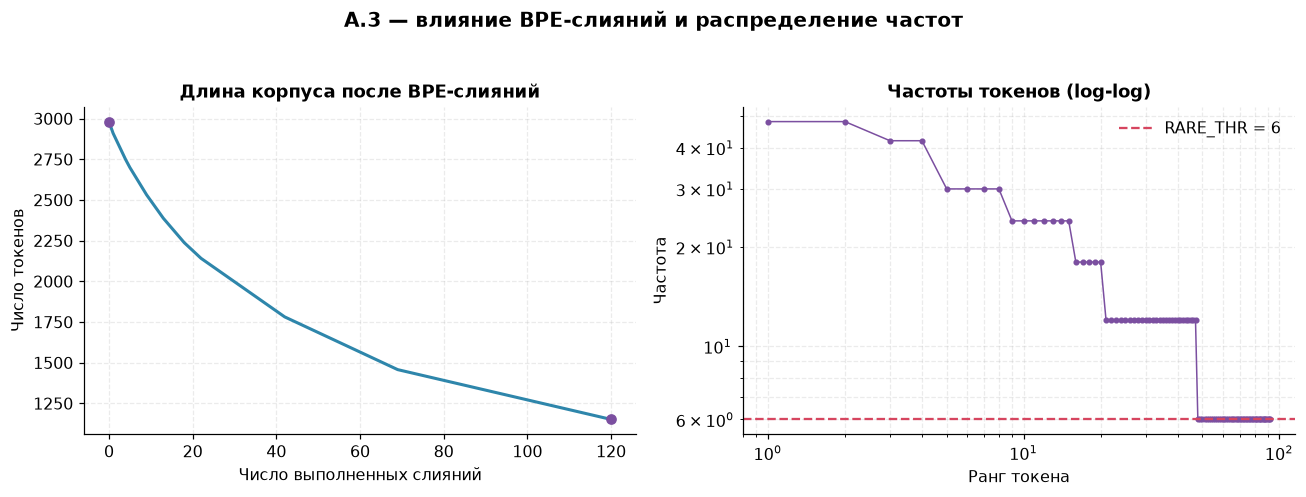

In [5]:
RARE_THR = 6

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ---------------------------------------------------------
# Слева: длина корпуса от числа выполненных слияний
# ---------------------------------------------------------

axes[0].plot(
    range(len(lengths)),
    lengths,
    linewidth=2,
    color=PALETTE["attn"]
)

axes[0].scatter(
    [0, len(lengths) - 1],
    [lengths[0], lengths[-1]],
    color=PALETTE["accent"],
    zorder=3
)

axes[0].set_title("Длина корпуса после BPE-слияний")
axes[0].set_xlabel("Число выполненных слияний")
axes[0].set_ylabel("Число токенов")
axes[0].grid(True, alpha=0.25, linestyle="--")


# ---------------------------------------------------------
# Справа: распределение частот токенов
# ---------------------------------------------------------

token_freqs = {}

for seq, freq in vocab.items():
    for token in seq:
        token_freqs[token] = token_freqs.get(token, 0) + freq

freqs_sorted = sorted(token_freqs.values(), reverse=True)
ranks = np.arange(1, len(freqs_sorted) + 1)

axes[1].loglog(
    ranks,
    freqs_sorted,
    marker="o",
    markersize=3,
    linewidth=1,
    color=PALETTE["accent"]
)

axes[1].axhline(
    RARE_THR,
    color=PALETTE["bad"],
    linestyle="--",
    linewidth=1.5,
    label=f"RARE_THR = {RARE_THR}"
)

axes[1].set_title("Частоты токенов (log-log)")
axes[1].set_xlabel("Ранг токена")
axes[1].set_ylabel("Частота")
axes[1].legend()

axes[1].grid(True, alpha=0.25, which="both", linestyle="--")

finish(fig, "A.3 — влияние BPE-слияний и распределение частот")

**Вопрос A.** Во сколько раз выросла бы стоимость слоя внимания, если перейти от BPE к посимвольной
токенизации при том же тексте? Используйте измеренный коэффициент сжатия и зависимость $O(n^2)$.

**Ответ A.** Сжатие получилось в 2.3 раза -> стоимость слоя внимания выросла бы в 5,3 раза

## Часть B. Затухание градиента в рекуррентной сети

Для рекуррентности $h_t = \phi(W h_{t-1} + U x_t)$ производная по состоянию, удалённому на $k$ шагов,
содержит произведение $k$ матриц:

$
\frac{\partial h_T}{\partial h_{T-k}} = \prod_{j=0}^{k-1} \operatorname{diag}(\phi')\, W .
$

Примерно можно считать, что градиент равен $W^k$

Норма такого произведения ведёт себя как $\rho(W)^k$. Аддитивный путь с гейтом $f_t$ даёт вместо
этого множитель $\prod f_t$, который при $f_t \to 1$ почти не затухает.

**Задание B.1.** Вычислите норму произведения $k$ матриц с заданным спектральным радиусом.
**Задание B.2.** Постройте график нормы от $k$ для $\rho \in \{0.9, 1.0, 1.2\}$ и добавьте
аддитивные пути с $f_t = 0.99$ и $f_t = 0.95$.
**Задание B.3.** Найдите эффективный горизонт памяти: при каком $k$ норма падает ниже $10^{-6}$.

In [6]:
def make_W(d, rho, gen):
    # матрица со заданным спектральным радиусом
    A = gen.normal(size=(d, d)) / np.sqrt(d)
    return A * rho / np.max(np.abs(np.linalg.eigvals(A)))

def grad_norms(rho, k_max=120, d=32, seed=0):
    gen = np.random.default_rng(seed)
    W = make_W(d, rho, gen)

    norms = []
    P = np.eye(d)

    for k in range(1, k_max + 1):
        P = P @ W
        norms.append(np.linalg.norm(P, 2))

    return np.array(norms)

def horizon(rho, thr=1e-6, k_max=4000, d=32, seed=0):
    # Ищем первое k, для которого rho**k < thr
    if rho <= 0:
        return 1
    
    if rho == 1:
        return None
    
    if rho > 1:
        return None
    
    k = int(np.ceil(np.log(thr) / np.log(rho)))
    
    if k > k_max:
        return None
    
    return k

print("Проверка:")
for rho in (0.9, 1.0, 1.2):
    print(
        "rho = %.1f | horizon = %s"
        % (rho, str(horizon(rho)))
    )

Проверка:
rho = 0.9 | horizon = 132
rho = 1.0 | horizon = None
rho = 1.2 | horizon = None


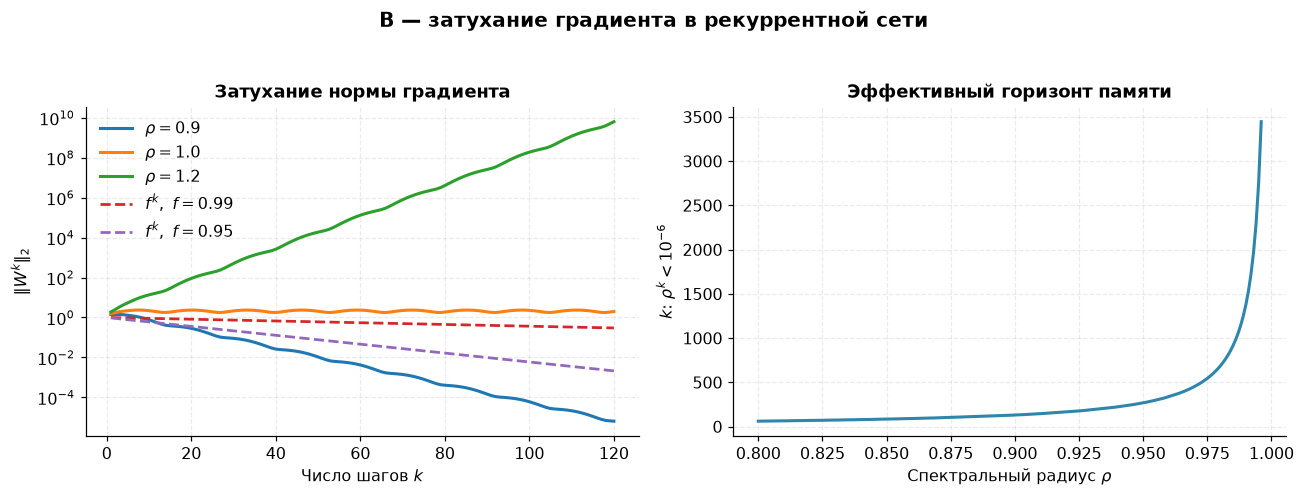

In [7]:
# Параметры эксперимента
rhos = (0.9, 1.0, 1.2)
k_max = 120
ks = np.arange(1, k_max + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ---------------------------------------------------------
# Слева: нормы произведения матриц
# ---------------------------------------------------------

for rho in rhos:
    norms = grad_norms(rho, k_max=k_max, d=D_CELL, seed=SEED)

    axes[0].plot(
        ks,
        norms,
        linewidth=2,
        label=rf"$\rho={rho}$"
    )

# Аддитивные пути: f^k
for f in (0.99, 0.95):
    axes[0].plot(
        ks,
        f ** ks,
        linestyle="--",
        linewidth=1.8,
        label=rf"$f^k,\ f={f}$"
    )

axes[0].set_yscale("log")
axes[0].set_title("Затухание нормы градиента")
axes[0].set_xlabel("Число шагов $k$")
axes[0].set_ylabel(r"$\|W^k\|_2$")
axes[0].legend()
axes[0].grid(True, alpha=0.25, which="both", linestyle="--")


# ---------------------------------------------------------
# Справа: эффективный горизонт памяти
# ---------------------------------------------------------

rho_grid = np.linspace(0.8, 0.999, 200)
horizons = np.array([
    horizon(rho, thr=1e-6, k_max=4000)
    for rho in rho_grid
])

axes[1].plot(
    rho_grid,
    horizons,
    linewidth=2,
    color=PALETTE["attn"]
)

axes[1].set_title("Эффективный горизонт памяти")
axes[1].set_xlabel(r"Спектральный радиус $\rho$")
axes[1].set_ylabel(r"$k$: $\rho^k < 10^{-6}$")
axes[1].grid(True, alpha=0.25, linestyle="--")

finish(fig, "B — затухание градиента в рекуррентной сети")

**Вопрос B.** Пусть требуется удерживать зависимость длиной 500 шагов с ослаблением сигнала не
более чем в 10 раз. Какое значение гейта $f_t$ для этого нужно? Сравните с $\rho(W)$, необходимым в
чистой рекуррентности.

**Ответ B.** f_t^500 < 0.1 . Для этого достаточно f_t = 0.996. В приближении $\rho(W)$ получается такое же

## Часть C. Внимание с нуля и роль масштабирования

$
\operatorname{Attention}(Q,K,V) = \operatorname{softmax}\!\left(\frac{QK^{\top}}{\sqrt{d_k}}\right) V .
$

Делитель $\sqrt{d_k}$ не косметика: при $q,k \sim \mathcal N(0,1)$ скалярное произведение имеет
дисперсию $d_k$, и без нормировки softmax при больших $d_k$ вырождается почти в one-hot, что
обнуляет градиент по ключам.

**Задание C.1.** Реализуйте одну голову внимания с каузальной маской и без неё.
**Задание C.2.** Проверьте два обязательных свойства: строки матрицы внимания суммируются в единицу,
а при каузальной маске верхний треугольник строго нулевой.
**Задание C.3.** Измерьте среднюю энтропию распределения внимания как функцию $d_k$ с делителем и
без него, постройте рисунок с картами внимания и графиком энтропии.

In [8]:
def attention(Q, K, V, causal=True, scale=True):
    # Q: (n_q, d_k)
    # K: (n_k, d_k)
    # V: (n_k, d_v)

    # 1. Сходство каждого query со всеми key
    scores = Q @ K.T

    # 2. Масштабирование
    if scale:
        d_k = Q.shape[-1]
        scores = scores / np.sqrt(d_k)

    # 3. Каузальная маска:
    #    позиция i не может смотреть в будущее j > i
    if causal:
        mask = np.triu(
            np.ones_like(scores, dtype=bool),
            k=1
        )
        scores = scores.copy()
        scores[mask] = -np.inf

    # 4. Устойчивый softmax по последней оси
    row_max = np.max(scores, axis=-1, keepdims=True)
    exp_scores = np.exp(scores - row_max)
    attention_weights = exp_scores / np.sum(
        exp_scores,
        axis=-1,
        keepdims=True
    )

    # 5. Взвешенная сумма значений
    output = attention_weights @ V

    return output, attention_weights

In [9]:
g = np.random.default_rng(SEED)

Qt = g.normal(size=(8, 16))
Kt = g.normal(size=(8, 16))
Vt = g.normal(size=(8, 3))

_, Wt = attention(
    Qt,
    Kt,
    Vt,
    causal=True,
    scale=True
)

# C.2a: сумма каждой строки должна быть равна 1
row_sums = Wt.sum(axis=1)

assert np.allclose(
    row_sums,
    1.0,
    atol=1e-10
)

# C.2b: верхний треугольник без диагонали должен быть нулевым
upper = np.triu(Wt, k=1)

assert np.allclose(
    upper,
    0.0,
    atol=1e-12
)

# C.2c: максимальное отклонение от единицы
max_row_error = np.max(np.abs(row_sums - 1.0))

print("Максимальное отклонение сумм строк от 1:",
      max_row_error)

print("Проверка C.2 пройдена.")

Максимальное отклонение сумм строк от 1: 2.220446049250313e-16
Проверка C.2 пройдена.


In [10]:
def mean_entropy(d_k, scale, n=64, trials=40, seed=0):
    rng = np.random.default_rng(seed)

    entropies = []

    for _ in range(trials):
        Q = rng.normal(size=(n, d_k))
        K = rng.normal(size=(n, d_k))
        V = rng.normal(size=(n, 1))

        _, W = attention(
            Q,
            K,
            V,
            causal=False,
            scale=scale
        )

        # Энтропия каждой строки:
        # H = -sum p * log(p)
        safe_W = np.clip(W, 1e-300, 1.0)
        H = -np.sum(
            safe_W * np.log(safe_W),
            axis=1
        )

        entropies.append(np.mean(H))

    return float(np.mean(entropies))

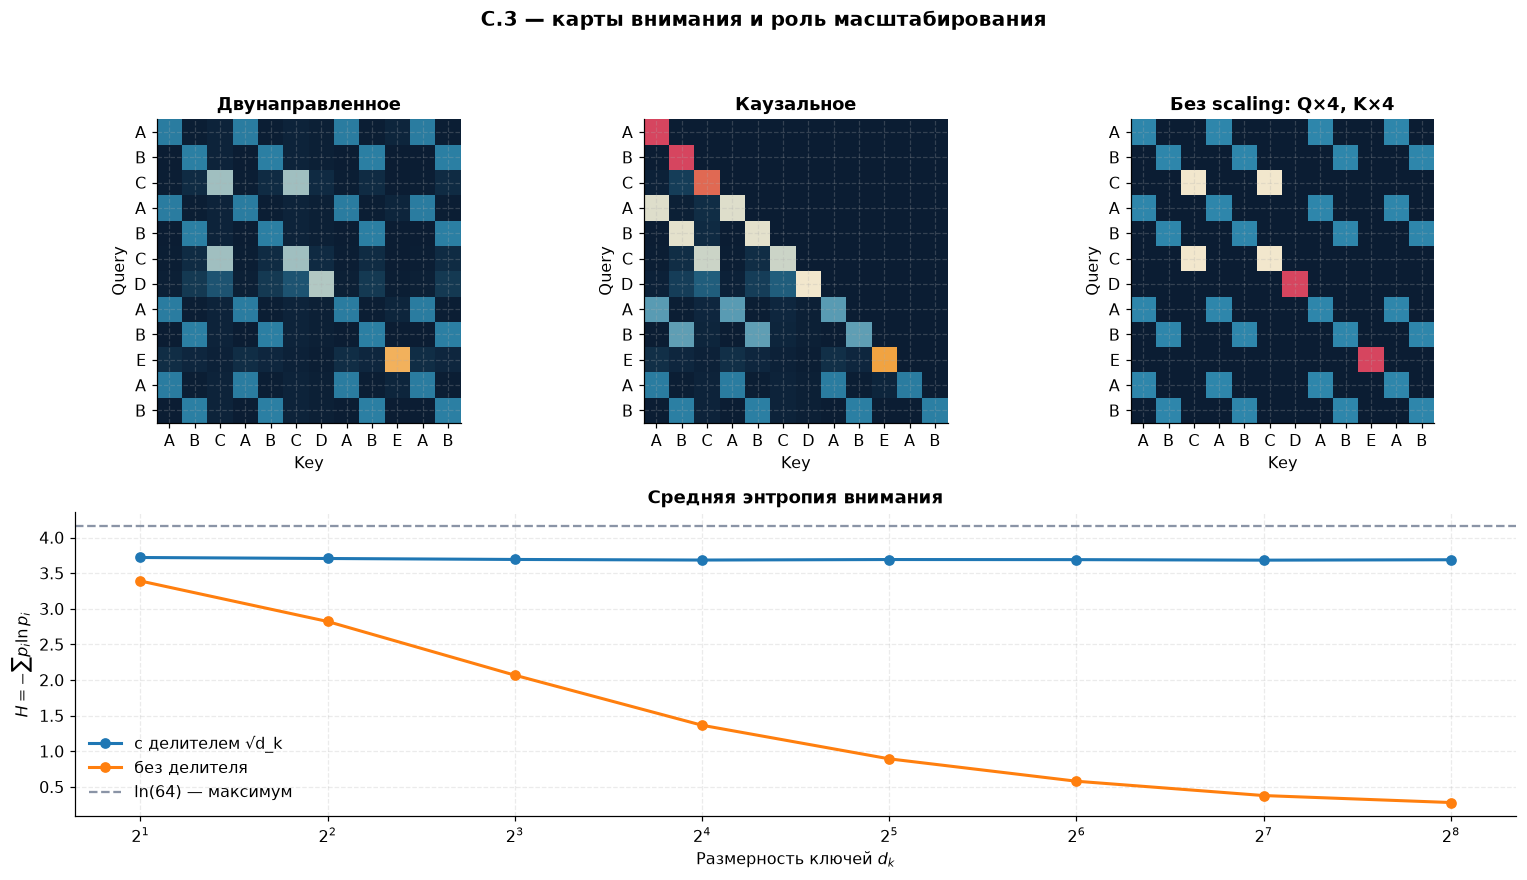

In [11]:
# Последовательность токенов
n_tok, d_k = 12, 16
labels = ["A", "B", "C", "A", "B", "C", "D", "A", "B", "E", "A", "B"]

# ------------------------------------------------------------
# Верхний ряд: карты внимания
# ------------------------------------------------------------

rng = np.random.default_rng(SEED)

# Сделаем эмбеддинги так, чтобы одинаковые labels
# имели похожие векторы.
base = {}

for label in sorted(set(labels)):
    base[label] = rng.normal(size=d_k)

Q = np.array([base[label] for label in labels])
K = np.array([base[label] for label in labels])
V = rng.normal(size=(n_tok, 3))

_, W_full = attention(
    Q,
    K,
    V,
    causal=False,
    scale=True
)

_, W_causal = attention(
    Q,
    K,
    V,
    causal=True,
    scale=True
)

# Без масштабирования
_, W_no_scale = attention(
    Q * 4,
    K * 4,
    V,
    causal=False,
    scale=False
)

# ------------------------------------------------------------
# Нижний ряд: энтропия от d_k
# ------------------------------------------------------------

d_grid = np.array([2, 4, 8, 16, 32, 64, 128, 256])

H_scaled = np.array([
    mean_entropy(
        d_k=d,
        scale=True,
        n=64,
        trials=40,
        seed=SEED
    )
    for d in d_grid
])

H_no_scale = np.array([
    mean_entropy(
        d_k=d,
        scale=False,
        n=64,
        trials=40,
        seed=SEED
    )
    for d in d_grid
])

H_max = np.log(64)

# ------------------------------------------------------------
# Рисуем
# ------------------------------------------------------------

fig = plt.figure(figsize=(14, 8))

# Верхние три карты
ax1 = plt.subplot(2, 3, 1)
im1 = ax1.imshow(W_full, cmap=CMAP_HEAT, vmin=0, vmax=1)
ax1.set_title("Двунаправленное")
ax1.set_xticks(range(n_tok))
ax1.set_yticks(range(n_tok))
ax1.set_xticklabels(labels)
ax1.set_yticklabels(labels)
ax1.set_xlabel("Key")
ax1.set_ylabel("Query")

ax2 = plt.subplot(2, 3, 2)
im2 = ax2.imshow(W_causal, cmap=CMAP_HEAT, vmin=0, vmax=1)
ax2.set_title("Каузальное")
ax2.set_xticks(range(n_tok))
ax2.set_yticks(range(n_tok))
ax2.set_xticklabels(labels)
ax2.set_yticklabels(labels)
ax2.set_xlabel("Key")
ax2.set_ylabel("Query")

ax3 = plt.subplot(2, 3, 3)
im3 = ax3.imshow(W_no_scale, cmap=CMAP_HEAT, vmin=0, vmax=1)
ax3.set_title("Без scaling: Q×4, K×4")
ax3.set_xticks(range(n_tok))
ax3.set_yticks(range(n_tok))
ax3.set_xticklabels(labels)
ax3.set_yticklabels(labels)
ax3.set_xlabel("Key")
ax3.set_ylabel("Query")

# Нижний график занимает всю ширину
ax4 = plt.subplot(2, 3, (4, 6))

ax4.plot(
    d_grid,
    H_scaled,
    marker="o",
    linewidth=2,
    label="с делителем √d_k"
)

ax4.plot(
    d_grid,
    H_no_scale,
    marker="o",
    linewidth=2,
    label="без делителя"
)

ax4.axhline(
    H_max,
    linestyle="--",
    linewidth=1.5,
    color=PALETTE["gray"],
    label=r"$\ln(64)$ — максимум"
)

ax4.set_xscale("log", base=2)
ax4.set_title("Средняя энтропия внимания")
ax4.set_xlabel(r"Размерность ключей $d_k$")
ax4.set_ylabel(r"$H=-\sum p_i\ln p_i$")
ax4.legend()
ax4.grid(True, alpha=0.25, which="both", linestyle="--")

finish(fig, "C.3 — карты внимания и роль масштабирования")

**Вопрос C.** Почему вырождение softmax в one-hot останавливает обучение? Свяжите ответ с
производной softmax по логитам.

**Ответ C.** Потому что практически все внимание уделяется только одному. Тогда производная (градиент) будет стремиться к нулю

## Часть D. Позиционные кодировки: синусоида, RoPE, ALiBi

Внимание перестановочно инвариантно, поэтому порядок вносится отдельно:

- синусоидальная кодировка добавляется к эмбеддингу (абсолютная позиция);
- **RoPE** поворачивает $q$ и $k$ на угол, пропорциональный позиции, так что
  $\langle R_t q, R_s k\rangle = f(q,k,t-s)$;
- **ALiBi** добавляет к логитам линейный штраф $-m|t-s|$.

**Задание D.1.** Реализуйте синусоидальную кодировку.
**Задание D.2.** Реализуйте RoPE и численно проверьте зависимость только от $t-s$: постройте
$\langle R_{t}q, R_{s}k\rangle$ для нескольких абсолютных начал при одинаковых разностях позиций.
**Задание D.3.** Постройте матрицу штрафов ALiBi для одной головы и рисунок из трёх панелей.

In [12]:
def sinusoidal(n, d):
    positions = np.arange(n)[:, None]
    dims = np.arange(d)[None, :]

    angles = positions / np.power(10000.0, (2 * (dims // 2)) / d)

    pe = np.zeros((n, d))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])

    return pe


def rope_apply(x, pos, base=10000.0):
    x = np.asarray(x, dtype=float)
    d = x.shape[-1]

    assert d % 2 == 0, "Размерность RoPE должна быть чётной"

    i = np.arange(d // 2)
    theta = pos / np.power(base, 2 * i / d)

    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)

    x1 = x[..., 0::2]
    x2 = x[..., 1::2]

    y1 = x1 * cos_theta - x2 * sin_theta
    y2 = x1 * sin_theta + x2 * cos_theta

    y = np.empty_like(x)
    y[..., 0::2] = y1
    y[..., 1::2] = y2

    return y


# D.2a: проверка зависимости только от относительной позиции
rng = np.random.default_rng(SEED)

q = rng.normal(size=D_MODEL)
k = rng.normal(size=D_MODEL)

starts = [0, 10, 100, 1000]
delta = 3

scores = []

for start in starts:
    t = start + delta
    s = start

    q_rot = rope_apply(q, t)
    k_rot = rope_apply(k, s)

    score = np.dot(q_rot, k_rot)
    scores.append(score)

scores = np.array(scores)

print("RoPE-проверка:")
for start, score in zip(starts, scores):
    print(
        "начало = %4d | t-s = %d | dot = %.10f"
        % (start, delta, score)
    )

max_diff = np.max(np.abs(scores - scores[0]))
print("Максимальное расхождение:", max_diff)

assert max_diff < 1e-10
print("Инвариантность к общему сдвигу позиций подтверждена.")

RoPE-проверка:
начало =    0 | t-s = 3 | dot = 2.2698884222
начало =   10 | t-s = 3 | dot = 2.2698884222
начало =  100 | t-s = 3 | dot = 2.2698884222
начало = 1000 | t-s = 3 | dot = 2.2698884222
Максимальное расхождение: 2.6645352591003757e-14
Инвариантность к общему сдвигу позиций подтверждена.


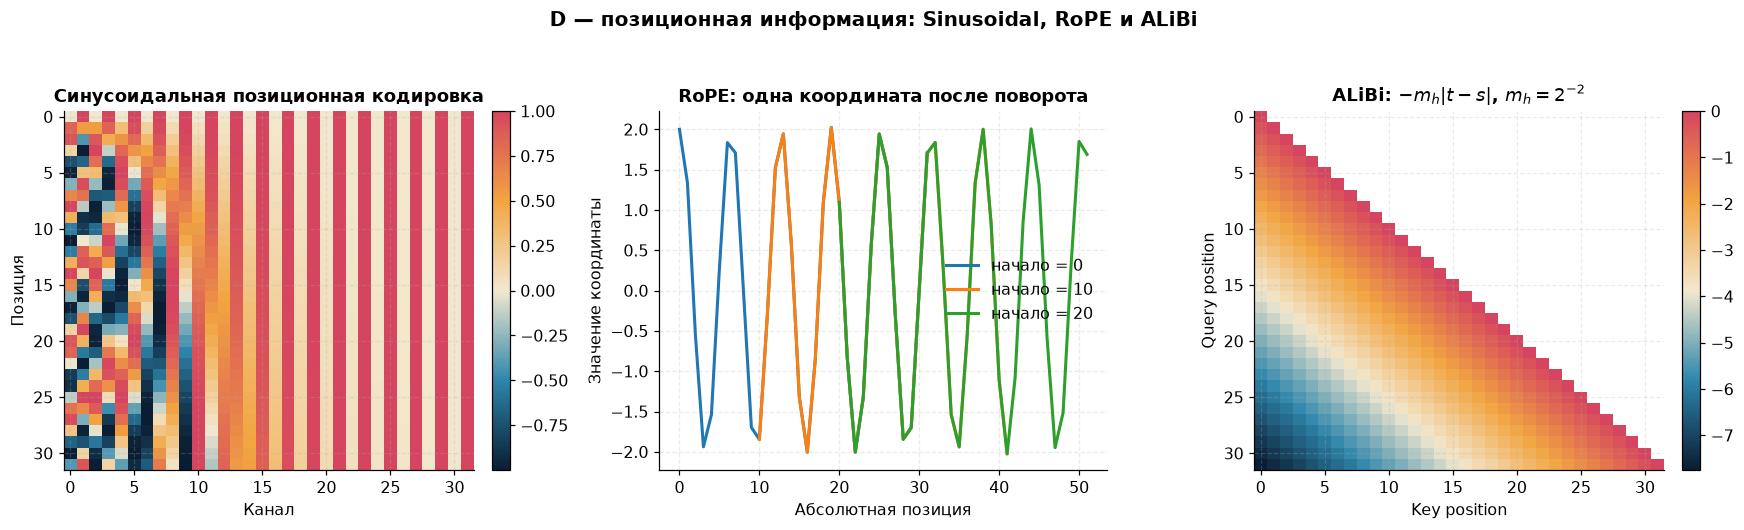

In [13]:
n_pos = 32
d_pos = 32

PE = sinusoidal(n_pos, d_pos)

# Для визуализации RoPE берём один вектор q
q_vis = rng.normal(size=D_MODEL)

rope_starts = [0, 10, 20]
rope_curves = []

for start in rope_starts:
    values = []
    for pos in range(start, start + n_pos):
        rotated = rope_apply(q_vis, pos)
        values.append(rotated[0])
    rope_curves.append(np.array(values))

# ALiBi
n_alibi = 32
positions = np.arange(n_alibi)
distance = np.abs(
    positions[:, None] - positions[None, :]
)

head = 2
m_h = 2.0 ** (-head)

alibi_penalty = -m_h * distance

# Будущее запрещаем
future_mask = np.triu(
    np.ones((n_alibi, n_alibi), dtype=bool),
    k=1
)
alibi_plot = alibi_penalty.astype(float)
alibi_plot[future_mask] = np.nan


fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# 1. Синусоидальная кодировка
im1 = axes[0].imshow(
    PE,
    aspect="auto",
    cmap=CMAP_HEAT
)
axes[0].set_title("Синусоидальная позиционная кодировка")
axes[0].set_xlabel("Канал")
axes[0].set_ylabel("Позиция")
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# 2. RoPE
for start, curve in zip(rope_starts, rope_curves):
    axes[1].plot(
        np.arange(start, start + n_pos),
        curve,
        linewidth=2,
        label=f"начало = {start}"
    )

axes[1].set_title("RoPE: одна координата после поворота")
axes[1].set_xlabel("Абсолютная позиция")
axes[1].set_ylabel("Значение координаты")
axes[1].legend()
axes[1].grid(True, alpha=0.25, linestyle="--")

# 3. ALiBi
im3 = axes[2].imshow(
    alibi_plot,
    aspect="auto",
    cmap=CMAP_HEAT
)
axes[2].set_title(
    rf"ALiBi: $-m_h|t-s|$, $m_h=2^{{-{head}}}$"
)
axes[2].set_xlabel("Key position")
axes[2].set_ylabel("Query position")
fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

finish(fig, "D — позиционная информация: Sinusoidal, RoPE и ALiBi")

**Вопрос D.** Какая из трёх схем позволяет работать с позициями, которых не было в обучении, и
почему? Что произойдёт с обучаемой абсолютной кодировкой при выходе за максимальную длину?

**Ответ D.** Все модели позволяют работать с позициями, которых не было в обучении. Они все вычисляют информации о позиции через формулу (синус/косинус, угол поворота или уменьшение score в зависимости от расстояния). Для абсолютной кодировки произойдет выход за границу, поскольку модель обучалась только на таблице токенов определенной размерности.

## Часть E. Мини-трансформер и индукционная голова

Задача **ассоциативного вспоминания**: последовательность пар «ключ, значение», затем повтор одного
из ключей; модель должна выдать соответствующее значение:

$
k_1\,v_1\,k_2\,v_2\,\dots\,k_N\,v_N\ \ k_i \;\longrightarrow\; v_i .
$

Минимальное решение — схема из двух слоёв (индукционная голова): первый слой переносит в позицию
ключа информацию о следующем токене, второй сравнивает финальный запрос с ключами.

**Задание E.1.** Реализуйте блок трансформера: пред-нормализация, одна голова каузального внимания,
FFN, остаточные связи.
**Задание E.2.** Обучите модель (обучение идёт на 2…`N_MAX` парах) и измерьте точность для
2…20 пар, включая длины больше обучающих.
**Задание E.3.** Постройте карты внимания обоих слоёв для одного примера и найдите индукционную
схему.

In [14]:
N_KEYS, N_VALS = 256, 16
VOCAB = N_KEYS + N_VALS

def make_recall_batch(bs, n_pairs, gen):
    keys = torch.stack([torch.randperm(N_KEYS, generator=gen)[:n_pairs] for _ in range(bs)])
    vals = torch.randint(N_KEYS, VOCAB, (bs, n_pairs), generator=gen)
    seq = torch.zeros(bs, 2 * n_pairs + 1, dtype=torch.long)
    seq[:, 0:2 * n_pairs:2] = keys
    seq[:, 1:2 * n_pairs:2] = vals
    qi = torch.randint(0, n_pairs, (bs,), generator=gen)
    seq[:, -1] = keys[torch.arange(bs), qi]
    return seq, vals[torch.arange(bs), qi], qi

class Block(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.d = d

        self.q = nn.Linear(d, d, bias=False)
        self.k = nn.Linear(d, d, bias=False)
        self.v = nn.Linear(d, d, bias=False)
        self.o = nn.Linear(d, d, bias=False)

        self.ln1 = nn.LayerNorm(d)
        self.ln2 = nn.LayerNorm(d)

        self.ff = nn.Sequential(
            nn.Linear(d, 4 * d),
            nn.GELU(),
            nn.Linear(4 * d, d)
        )

    def forward(self, h, ret=False):
        # h: (batch, time, d)
        x = self.ln1(h)
        T = h.shape[1]

        # Получаем Query, Key, Value
        q = self.q(x)
        k = self.k(x)
        v = self.v(x)

        # Attention scores
        s = q @ k.transpose(1, 2) / math.sqrt(self.d)

        # Каузальная маска: запрещаем смотреть в будущее
        mask = torch.triu(
            torch.ones(
                T, T,
                dtype=torch.bool,
                device=h.device
            ),
            diagonal=1
        )

        s = s.masked_fill(mask, float("-inf"))

        # Превращаем scores в вероятности внимания
        att = s.softmax(dim=-1)

        # Взвешенная сумма Value
        a = att @ v

        # Первая residual connection
        h = h + self.o(a)

        # FFN + вторая residual connection
        h = h + self.ff(self.ln2(h))

        if ret:
            return h, att

        return h, None


class TinyTransformer(nn.Module):
    def __init__(self, d=64, max_len=90, n_layers=2):
        super().__init__()

        self.emb = nn.Embedding(VOCAB, d)
        self.pos = nn.Embedding(max_len, d)

        self.blocks = nn.ModuleList(
            [Block(d) for _ in range(n_layers)]
        )

        self.lnf = nn.LayerNorm(d)
        self.head = nn.Linear(d, VOCAB)

    def forward(self, x, ret=False):
        # x: (batch, time)
        positions = torch.arange(
            x.shape[1],
            device=x.device
        )

        h = self.emb(x) + self.pos(positions)

        maps = []

        for b in self.blocks:
            h, a = b(h, ret)
            maps.append(a)

        # Нам нужен только последний токен:
        # именно он содержит запрос k_i
        logits = self.head(self.lnf(h)[:, -1])

        return logits, maps


print(
    "размер словаря задачи:",
    VOCAB,
    "| случайное угадывание: %.3f" % (1 / N_VALS)
)

размер словаря задачи: 272 | случайное угадывание: 0.062


In [15]:
def train_recall(steps=2600, bs=64, lr=2e-3, seed=0, n_max=12):
    gen = torch.Generator().manual_seed(seed)

    m = TinyTransformer(d=D_MODEL)

    opt = torch.optim.AdamW(
        m.parameters(),
        lr=lr,
        weight_decay=0.01
    )

    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt,
        max_lr=lr,
        total_steps=steps,
        pct_start=0.15
    )

    curve = []

    for s in range(steps):
        # На каждом шаге случайная длина последовательности
        n = int(
            torch.randint(
                2,
                n_max + 1,
                (1,),
                generator=gen
            )
        )

        x, y, _ = make_recall_batch(bs, n, gen)

        # Прямой проход
        logits, _ = m(x)

        # Правильный ответ — значение, соответствующее
        # последнему ключу-запросу
        loss = F.cross_entropy(logits, y)

        # Обратное распространение
        opt.zero_grad()
        loss.backward()

        # Защита от слишком больших градиентов
        torch.nn.utils.clip_grad_norm_(
            m.parameters(),
            max_norm=1.0
        )

        opt.step()
        sched.step()

        curve.append(float(loss.detach()))

    return m, curve, gen


def acc_vs_pairs(m, gen, ns, bs=256):
    m.eval()

    accs = []

    with torch.no_grad():
        for n in ns:
            x, y, _ = make_recall_batch(
                bs,
                n,
                gen
            )

            logits, _ = m(x)

            pred = logits.argmax(dim=-1)

            acc = (pred == y).float().mean().item()

            accs.append(acc)

    m.train()

    return accs


NS = [2, 4, 6, 8, 10, 12, 16, 20]

t0 = time.time()

model, curve, gen_m = train_recall(
    seed=SEED,
    n_max=N_MAX
)

acc = acc_vs_pairs(
    model,
    gen_m,
    NS
)

print(
    "обучение заняло %.0f c"
    % (time.time() - t0)
)

print(
    "точность по числу пар:",
    dict(
        zip(
            NS,
            [round(a, 3) for a in acc]
        )
    )
)

обучение заняло 41 c
точность по числу пар: {2: 1.0, 4: 1.0, 6: 1.0, 8: 1.0, 10: 0.777, 12: 0.598, 16: 0.535, 20: 0.402}


Пример:
tokens: [254, 268, 230, 264, 170, 267, 249, 266, 140, 259, 74, 269, 254]
запрос: 254
правильный ответ: 268
предсказание: 268
позиция правильной пары: 0


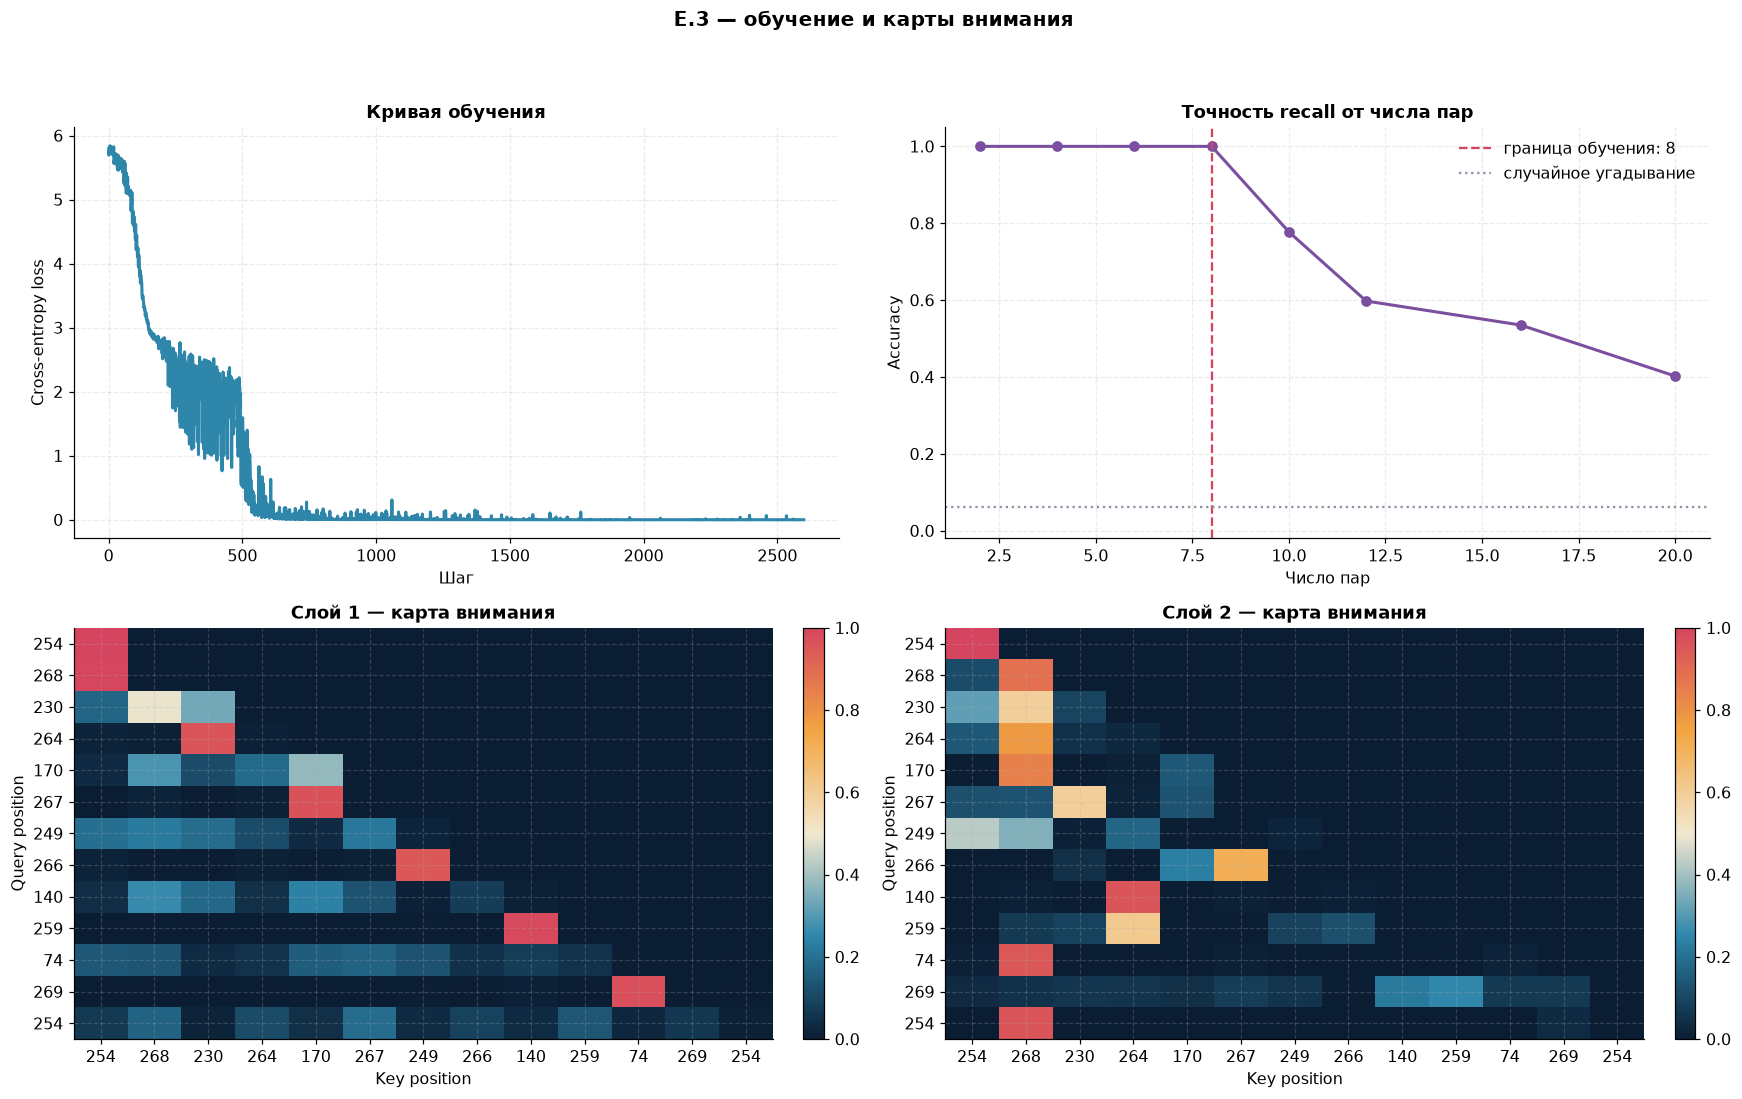

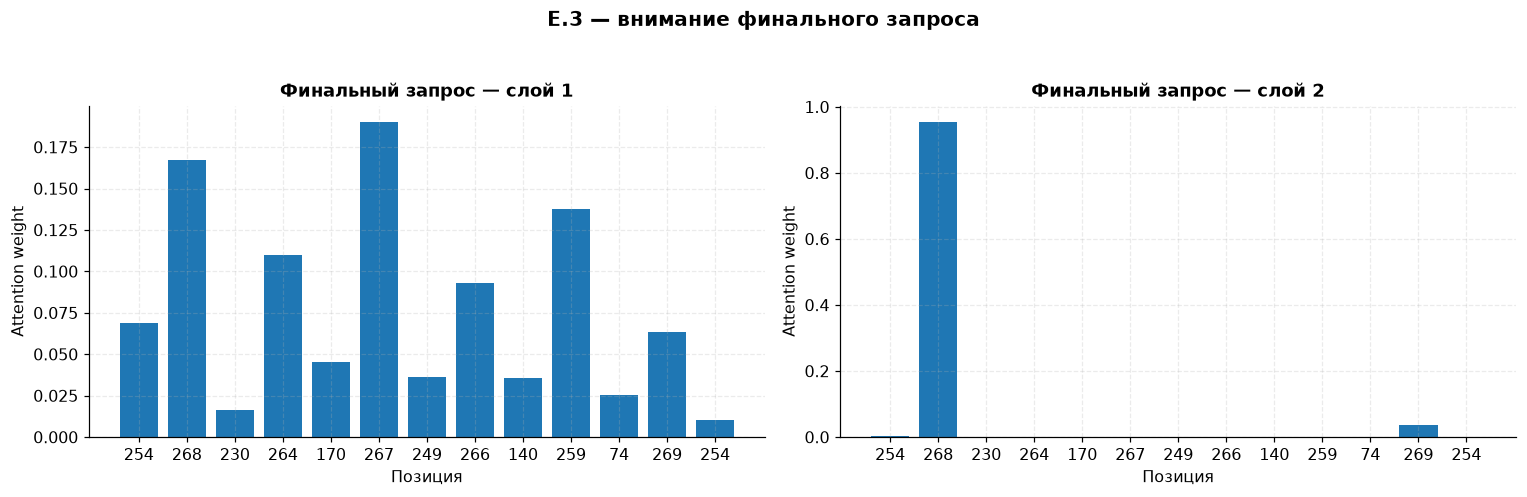

TinyTransformer(
  (emb): Embedding(272, 64)
  (pos): Embedding(90, 64)
  (blocks): ModuleList(
    (0-1): 2 x Block(
      (q): Linear(in_features=64, out_features=64, bias=False)
      (k): Linear(in_features=64, out_features=64, bias=False)
      (v): Linear(in_features=64, out_features=64, bias=False)
      (o): Linear(in_features=64, out_features=64, bias=False)
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (ff): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=256, out_features=64, bias=True)
      )
    )
  )
  (lnf): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  (head): Linear(in_features=64, out_features=272, bias=True)
)

In [16]:
# Один фиксированный пример для визуализации
x_ex, y_ex, qi_ex = make_recall_batch(
    1,
    6,
    torch.Generator().manual_seed(123)
)

model.eval()

with torch.no_grad():
    logits_ex, maps = model(x_ex, ret=True)

pred_ex = logits_ex.argmax(dim=-1).item()

tokens_ex = x_ex[0].tolist()
answer_ex = y_ex.item()
query_ex = tokens_ex[-1]

print("Пример:")
print("tokens:", tokens_ex)
print("запрос:", query_ex)
print("правильный ответ:", answer_ex)
print("предсказание:", pred_ex)
print("позиция правильной пары:", qi_ex.item())

# ---------------------------------------------------------
# Рисуем всё
# ---------------------------------------------------------

fig = plt.figure(figsize=(16, 10))

# 1. Кривая обучения
ax1 = plt.subplot(2, 2, 1)

ax1.plot(
    curve,
    linewidth=2,
    color=PALETTE["attn"]
)

ax1.set_title("Кривая обучения")
ax1.set_xlabel("Шаг")
ax1.set_ylabel("Cross-entropy loss")
ax1.grid(True, alpha=0.25, linestyle="--")


# 2. Точность от количества пар
ax2 = plt.subplot(2, 2, 2)

ax2.plot(
    NS,
    acc,
    marker="o",
    linewidth=2,
    color=PALETTE["accent"]
)

# Отмечаем границу обучения
ax2.axvline(
    N_MAX,
    linestyle="--",
    linewidth=1.5,
    color=PALETTE["bad"],
    label=f"граница обучения: {N_MAX}"
)

ax2.axhline(
    1 / N_VALS,
    linestyle=":",
    linewidth=1.5,
    color=PALETTE["gray"],
    label="случайное угадывание"
)

ax2.set_title("Точность recall от числа пар")
ax2.set_xlabel("Число пар")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(-0.02, 1.05)
ax2.legend()
ax2.grid(True, alpha=0.25, linestyle="--")


# ---------------------------------------------------------
# Подготовка карт внимания
# ---------------------------------------------------------

tokens_ex = np.array(tokens_ex)

att1 = maps[0][0].cpu().numpy()
att2 = maps[1][0].cpu().numpy()

# 3. Attention layer 1
ax3 = plt.subplot(2, 2, 3)

im1 = ax3.imshow(
    att1,
    aspect="auto",
    cmap=CMAP_HEAT,
    vmin=0,
    vmax=1
)

ax3.set_title("Слой 1 — карта внимания")
ax3.set_xlabel("Key position")
ax3.set_ylabel("Query position")

ax3.set_xticks(range(len(tokens_ex)))
ax3.set_yticks(range(len(tokens_ex)))

ax3.set_xticklabels(tokens_ex)
ax3.set_yticklabels(tokens_ex)

fig.colorbar(
    im1,
    ax=ax3,
    fraction=0.046,
    pad=0.04
)


# 4. Attention layer 2
ax4 = plt.subplot(2, 2, 4)

im2 = ax4.imshow(
    att2,
    aspect="auto",
    cmap=CMAP_HEAT,
    vmin=0,
    vmax=1
)

ax4.set_title("Слой 2 — карта внимания")
ax4.set_xlabel("Key position")
ax4.set_ylabel("Query position")

ax4.set_xticks(range(len(tokens_ex)))
ax4.set_yticks(range(len(tokens_ex)))

ax4.set_xticklabels(tokens_ex)
ax4.set_yticklabels(tokens_ex)

fig.colorbar(
    im2,
    ax=ax4,
    fraction=0.046,
    pad=0.04
)

finish(fig, "E.3 — обучение и карты внимания")


# ---------------------------------------------------------
# Отдельно: внимание финального запроса
# ---------------------------------------------------------

final_att_layer1 = att1[-1]
final_att_layer2 = att2[-1]

positions = np.arange(len(tokens_ex))

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4.5)
)

axes[0].bar(
    positions,
    final_att_layer1
)

axes[0].set_title("Финальный запрос — слой 1")
axes[0].set_xlabel("Позиция")
axes[0].set_ylabel("Attention weight")
axes[0].set_xticks(positions)
axes[0].set_xticklabels(tokens_ex)
axes[0].grid(True, alpha=0.25, linestyle="--")

axes[1].bar(
    positions,
    final_att_layer2
)

axes[1].set_title("Финальный запрос — слой 2")
axes[1].set_xlabel("Позиция")
axes[1].set_ylabel("Attention weight")
axes[1].set_xticks(positions)
axes[1].set_xticklabels(tokens_ex)
axes[1].grid(True, alpha=0.25, linestyle="--")

finish(
    fig,
    "E.3 — внимание финального запроса"
)

model.train()

**Вопрос E.** Почему для этой задачи недостаточно одного слоя внимания? Опишите, какую информацию
переносит первый слой и что именно сравнивает второй.

**Ответ E.** Потому что сначала нужно понять какому ключу соответствует каждое значение (1 голова), а потом найти значение по ключу (2 голова)

## Часть F. Линейное внимание: состояние вместо матрицы внимания

Если заменить $\exp(q^\top k)$ на $\varphi(q)^\top \varphi(k)$ с неотрицательным $\varphi$, сумму
можно переставить и получить рекуррентную форму с состоянием фиксированного размера:

$
S_t = S_{t-1} + \varphi(k_t) v_t^{\top}, \qquad
o_t = \frac{\varphi(q_t)^{\top} S_t}{\varphi(q_t)^{\top} z_t}, \qquad z_t = z_{t-1} + \varphi(k_t).
$

Генерация становится $O(1)$ по памяти, но состояние размера $d \times d$ — это фиксированная
ёмкость, в которую нужно уложить весь контекст.

**Задание F.1.** Реализуйте параллельную и рекуррентную формы линейного внимания и проверьте, что
они дают один результат.
**Задание F.2.** Измерьте ёмкость состояния: сложите в $S$ ровно $N$ пар «ключ–значение» и оцените
качество чтения (косинусная близость к истинному значению) при росте $N$.
**Задание F.3.** Постройте рисунок: рост KV-кэша softmax-внимания против постоянного состояния
линейного внимания и кривую качества чтения от числа сохранённых пар.

F.1
размер выхода: (40, 32)
максимальное расхождение: 2.384185791015625e-07
размер состояния: S = (32, 32) , z = (32,)
всего чисел в состоянии: 1056

F.2
N =   1 -> средняя cosine similarity = 1.0000
N =   2 -> средняя cosine similarity = 0.8147
N =   4 -> средняя cosine similarity = 0.6262
N =   8 -> средняя cosine similarity = 0.4689
N =  16 -> средняя cosine similarity = 0.3384
N =  32 -> средняя cosine similarity = 0.2457
N =  64 -> средняя cosine similarity = 0.1750
N = 128 -> средняя cosine similarity = 0.1241
N = 256 -> средняя cosine similarity = 0.0881


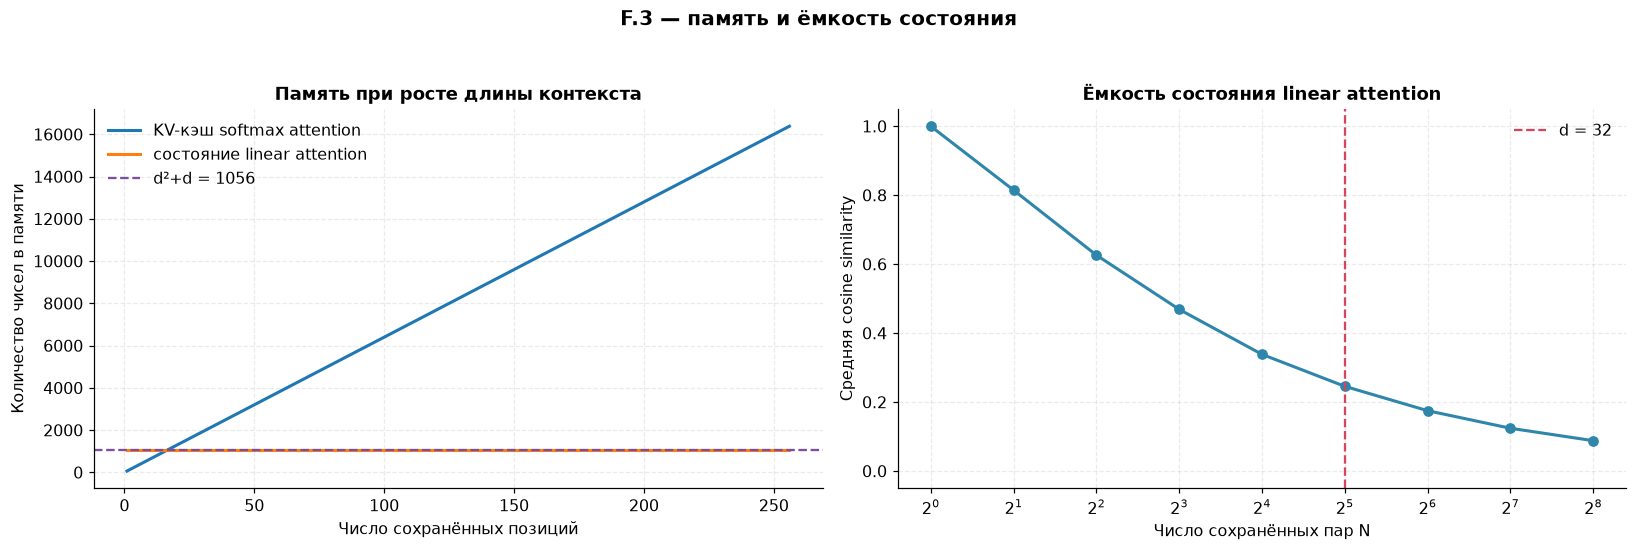

In [17]:
def phi(x):
    return torch.nn.functional.elu(x) + 1


def linear_attention_parallel(Q, K, V):
    """
    Параллельная форма линейного внимания.

    S_t = sum_{s <= t} phi(k_s) v_s^T
    z_t = sum_{s <= t} phi(k_s)

    o_t = [phi(q_t)^T S_t] / [phi(q_t)^T z_t]
    """
    phi_q = phi(Q)                         # (T, d)
    phi_k = phi(K)                         # (T, d)

    # Для каждого t:
    # phi(k_t) v_t^T -> матрица d x d
    kv = phi_k[:, :, None] * V[:, None, :] # (T, d, d)

    # Накопленные состояния до каждой позиции
    S = torch.cumsum(kv, dim=0)            # (T, d, d)
    z = torch.cumsum(phi_k, dim=0)         # (T, d)

    # phi(q_t)^T S_t
    numerator = torch.einsum("td,tdv->tv", phi_q, S)

    # phi(q_t)^T z_t
    denominator = torch.sum(phi_q * z, dim=-1, keepdim=True)

    return numerator / denominator.clamp_min(1e-8)


def linear_attention_recurrent(Q, K, V):
    """
    Рекуррентная форма линейного внимания.

    На каждом шаге храним только:
        S: d x d
        z: d
    """
    phi_q = phi(Q)
    phi_k = phi(K)

    T, d = Q.shape

    S = torch.zeros(d, d, dtype=Q.dtype, device=Q.device)
    z = torch.zeros(d, dtype=Q.dtype, device=Q.device)

    outputs = []

    for t in range(T):
        S = S + torch.outer(phi_k[t], V[t])
        z = z + phi_k[t]

        numerator = phi_q[t] @ S
        denominator = phi_q[t] @ z

        o_t = numerator / denominator.clamp_min(1e-8)
        outputs.append(o_t)

    return torch.stack(outputs, dim=0)


torch.manual_seed(SEED)

T_l, d_l = 40, 32
Ql = torch.randn(T_l, d_l)
Kl = torch.randn(T_l, d_l)
Vl = torch.randn(T_l, d_l)

out_parallel = linear_attention_parallel(Ql, Kl, Vl)
out_recurrent = linear_attention_recurrent(Ql, Kl, Vl)

max_diff = torch.max(torch.abs(out_parallel - out_recurrent)).item()

state_floats = d_l * d_l + d_l

print("F.1")
print("размер выхода:", tuple(out_parallel.shape))
print("максимальное расхождение:", max_diff)
print("размер состояния: S =", (d_l, d_l), ", z =", (d_l,))
print("всего чисел в состоянии:", state_floats)


# ------------------------------------------------------------
# F.2 — ёмкость состояния
# ------------------------------------------------------------

NS_CAP = [1, 2, 4, 8, 16, 32, 64, 128, 256]

gen_cap = torch.Generator().manual_seed(SEED + 1)
n_trials = 100

capacity_scores = []

for N in NS_CAP:
    trial_scores = []

    for _ in range(n_trials):
        keys = torch.randn(N, d_l, generator=gen_cap)
        values = torch.randn(N, d_l, generator=gen_cap)

        phi_keys = phi(keys)

        # Сжимаем все N пар в одно состояние
        S = phi_keys.T @ values
        z = phi_keys.sum(dim=0)

        # Пытаемся прочитать каждое исходное значение,
        # используя соответствующий ключ как запрос
        phi_queries = phi(keys)

        numerator = phi_queries @ S
        denominator = torch.sum(phi_queries * z, dim=-1, keepdim=True)

        retrieved = numerator / denominator.clamp_min(1e-8)

        # Косинусная близость каждого восстановленного
        # значения с истинным значением
        cos = F.cosine_similarity(retrieved, values, dim=-1)

        trial_scores.append(cos.mean().item())

    capacity_scores.append(float(np.mean(trial_scores)))

print("\nF.2")
for N, score in zip(NS_CAP, capacity_scores):
    print("N = %3d -> средняя cosine similarity = %.4f" % (N, score))


# ------------------------------------------------------------
# F.3 — рисунок
# ------------------------------------------------------------

# Softmax attention:
# для последовательности длины n нужно хранить K и V:
# K: n*d, V: n*d -> всего 2*n*d чисел.
n_memory = np.arange(1, 257)

kv_cache = 2 * n_memory * d_l

# Linear attention:
# S имеет d*d чисел, z имеет d чисел.
linear_state = d_l * d_l + d_l
linear_memory = np.full_like(n_memory, linear_state, dtype=float)

fig = plt.figure(figsize=(15, 5))

# Левая часть — память
ax1 = plt.subplot(1, 2, 1)

ax1.plot(
    n_memory,
    kv_cache,
    linewidth=2,
    label="KV-кэш softmax attention"
)

ax1.plot(
    n_memory,
    linear_memory,
    linewidth=2,
    label="состояние linear attention"
)

ax1.axhline(
    linear_state,
    linestyle="--",
    linewidth=1.5,
    color=PALETTE["accent"],
    label=f"d²+d = {linear_state}"
)

ax1.set_title("Память при росте длины контекста")
ax1.set_xlabel("Число сохранённых позиций")
ax1.set_ylabel("Количество чисел в памяти")
ax1.legend()
ax1.grid(True, alpha=0.25, linestyle="--")


# Правая часть — качество чтения
ax2 = plt.subplot(1, 2, 2)

ax2.plot(
    NS_CAP,
    capacity_scores,
    marker="o",
    linewidth=2,
    color=PALETTE["attn"]
)

ax2.axvline(
    d_l,
    linestyle="--",
    linewidth=1.5,
    color=PALETTE["bad"],
    label=f"d = {d_l}"
)

ax2.set_xscale("log", base=2)
ax2.set_ylim(-0.05, 1.05)
ax2.set_title("Ёмкость состояния linear attention")
ax2.set_xlabel("Число сохранённых пар N")
ax2.set_ylabel("Средняя cosine similarity")
ax2.legend()
ax2.grid(True, alpha=0.25, linestyle="--")

finish(fig, "F.3 — память и ёмкость состояния")

**Вопрос F.** Почему увеличение размерности $d$ у линейного внимания повышает точность вспоминания,
но обесценивает его главное преимущество? Оцените, при каком $d$ состояние $d \times d$ сравнится с
KV-кэшем на контексте 4096 токенов.

**Ответ F.** KV кэш на 4096 токенах: 2 * 4096 * d = 8192*d. Тогда d = 8191

## Часть G. Избирательная рекуррентность

Если сделать затухание и запись зависящими от входа

$
h_t = a(x_t) \odot h_{t-1} + b(x_t) \odot u(x_t),
$

то модель получает управляемую память: она может удерживать нужное и игнорировать шум. Это ядро
идеи моделей пространства состояний с избирательностью (Mamba).

Задача: в последовательности длины 64 встречается маркер `FLAG`; нужно назвать символ,
стоящий сразу после него. Всё остальное — шум.

**Задание G.1.** Реализуйте два варианта ячейки: с гейтами, зависящими от входа, и с обучаемым, но
постоянным затуханием.
**Задание G.2.** Обучите оба варианта и сравните точность.
**Задание G.3.** Постройте профили гейтов по позициям и оцените долю каналов, у которых гейт
сохранения превышает 0.9.

In [18]:
VOC_S, FLAG, T_S = 20, 19, 64


def flag_batch(bs, gen):
    x = torch.randint(0, 16, (bs, T_S), generator=gen)
    pos = torch.randint(2, T_S - 2, (bs,), generator=gen)
    tgt = torch.randint(0, 16, (bs,), generator=gen)

    x[torch.arange(bs), pos] = FLAG
    x[torch.arange(bs), pos + 1] = tgt

    return x, tgt, pos


class RecurCell(nn.Module):
    def __init__(self, d=48, selective=True):
        super().__init__()
        self.selective = selective

        self.emb = nn.Embedding(VOC_S, d)

        # Локальное окно из текущего и предыдущего токена
        self.inp = nn.Linear(2 * d, d)

        if selective:
            # Гейты зависят от текущего локального контекста
            self.ga = nn.Linear(2 * d, d)
            self.gb = nn.Linear(2 * d, d)
        else:
            # Один обучаемый коэффициент затухания на канал
            self.logit_a = nn.Parameter(torch.zeros(d))

        self.head = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, VOC_S)
        )

    def forward(self, x, return_gates=False):
        e = self.emb(x)

        B, Tn, d = e.shape

        # Для каждой позиции собираем:
        # [текущий токен, предыдущий токен]
        e_prev = torch.cat(
            [torch.zeros(B, 1, d), e[:, :-1]],
            dim=1
        )

        ctx = torch.cat([e, e_prev], dim=-1)

        # Локальное преобразование входа
        u = self.inp(ctx)

        if self.selective:
            # Гейты вычисляются отдельно для каждой позиции
            a = torch.sigmoid(self.ga(ctx))
            b = torch.sigmoid(self.gb(ctx))
        else:
            # Постоянное затухание для каждой координаты
            a_const = torch.sigmoid(self.logit_a)

            a = a_const.view(1, 1, d).expand(B, Tn, d)

            # Запись всегда разрешена полностью
            b = torch.ones_like(a)

        # Начальное состояние памяти
        h = torch.zeros(B, d, device=x.device)

        states = []

        for t in range(Tn):
            h = a[:, t] * h + b[:, t] * u[:, t]
            states.append(h)

        h_all = torch.stack(states, dim=1)

        logits = self.head(h_all)

        if return_gates:
            return logits, (a, b)

        return logits

In [20]:
def train_cell(selective, steps=600, bs=64, lr=5e-3, seed=0):
    gen = torch.Generator().manual_seed(seed)

    m = RecurCell(d=D_CELL, selective=selective)

    opt = torch.optim.AdamW(m.parameters(), lr=lr)

    curve = []

    for s in range(steps):
        x, y, _ = flag_batch(bs, gen)

        logits = m(x)

        # Предсказываем target по последней позиции
        loss = F.cross_entropy(logits[:, -1], y)

        opt.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            m.parameters(),
            max_norm=1.0
        )

        opt.step()

        # Каждые 25 шагов проверяем точность
        if (s + 1) % 25 == 0:
            with torch.no_grad():
                x_val, y_val, _ = flag_batch(256, gen)
                logits_val = m(x_val)
                pred = logits_val[:, -1].argmax(dim=-1)

                acc = (pred == y_val).float().mean().item()

            curve.append((s + 1, acc))

    return m, curve, gen


t0 = time.time()

cell_sel, curve_sel, gen_sel = train_cell(
    True,
    seed=SEED
)

cell_fix, curve_fix, gen_fix = train_cell(
    False,
    seed=SEED
)

print(
    "избирательная ячейка: точность %.3f"
    % curve_sel[-1][1]
)

print(
    "фиксированное затухание: точность %.3f (угадывание %.3f)"
    % (curve_fix[-1][1], 1 / 16)
)

print(
    "обучение заняло %.0f c"
    % (time.time() - t0)
)

избирательная ячейка: точность 1.000
фиксированное затухание: точность 0.078 (угадывание 0.062)
обучение заняло 25 c


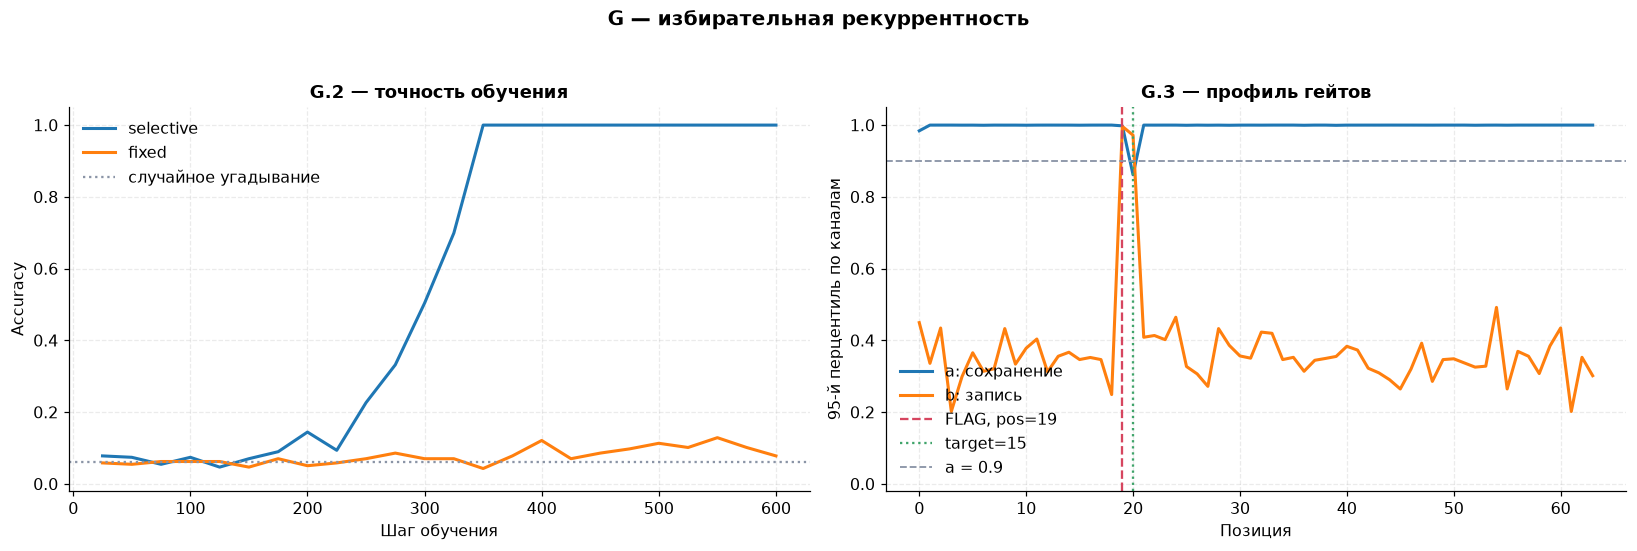

FLAG position: 19
target: 15
prediction: 15
доля каналов с a > 0.9 на FLAG: 0.146
доля каналов с a > 0.9 после FLAG: 0.042


RecurCell(
  (emb): Embedding(20, 48)
  (inp): Linear(in_features=96, out_features=48, bias=True)
  (ga): Linear(in_features=96, out_features=48, bias=True)
  (gb): Linear(in_features=96, out_features=48, bias=True)
  (head): Sequential(
    (0): LayerNorm((48,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): Linear(in_features=48, out_features=20, bias=True)
  )
)

In [21]:
# Кривые обучения
steps_sel = [x[0] for x in curve_sel]
acc_sel = [x[1] for x in curve_sel]

steps_fix = [x[0] for x in curve_fix]
acc_fix = [x[1] for x in curve_fix]

fig = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(1, 2, 1)

ax1.plot(
    steps_sel,
    acc_sel,
    linewidth=2,
    label="selective"
)

ax1.plot(
    steps_fix,
    acc_fix,
    linewidth=2,
    label="fixed"
)

ax1.axhline(
    1 / 16,
    linestyle=":",
    linewidth=1.5,
    color=PALETTE["gray"],
    label="случайное угадывание"
)

ax1.set_title("G.2 — точность обучения")
ax1.set_xlabel("Шаг обучения")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(-0.02, 1.05)
ax1.legend()
ax1.grid(True, alpha=0.25, linestyle="--")


# Один пример последовательности
xs, ys, pos = flag_batch(
    1,
    torch.Generator().manual_seed(77)
)

cell_sel.eval()

with torch.no_grad():
    logits_g, (a_g, b_g) = cell_sel(
        xs,
        return_gates=True
    )

pred_g = logits_g[:, -1].argmax(dim=-1).item()

tokens_g = xs[0].tolist()
target_g = ys.item()
flag_pos = pos.item()


# 95-й перцентиль по каналам
a_profile = torch.quantile(
    a_g[0],
    0.95,
    dim=-1
).cpu().numpy()

b_profile = torch.quantile(
    b_g[0],
    0.95,
    dim=-1
).cpu().numpy()

positions = np.arange(T_S)

ax2 = plt.subplot(1, 2, 2)

ax2.plot(
    positions,
    a_profile,
    linewidth=2,
    label="a: сохранение"
)

ax2.plot(
    positions,
    b_profile,
    linewidth=2,
    label="b: запись"
)

ax2.axvline(
    flag_pos,
    linestyle="--",
    linewidth=1.5,
    color=PALETTE["bad"],
    label=f"FLAG, pos={flag_pos}"
)

ax2.axvline(
    flag_pos + 1,
    linestyle=":",
    linewidth=1.5,
    color=PALETTE["good"],
    label=f"target={target_g}"
)

ax2.axhline(
    0.9,
    linestyle="--",
    linewidth=1.2,
    color=PALETTE["gray"],
    label="a = 0.9"
)

ax2.set_title("G.3 — профиль гейтов")
ax2.set_xlabel("Позиция")
ax2.set_ylabel("95-й перцентиль по каналам")
ax2.set_ylim(-0.02, 1.05)
ax2.legend()
ax2.grid(True, alpha=0.25, linestyle="--")

finish(fig, "G — избирательная рекуррентность")

print("FLAG position:", flag_pos)
print("target:", target_g)
print("prediction:", pred_g)

# Доля каналов, где a > 0.9
a_at_flag = a_g[0, flag_pos]
a_after_flag = a_g[0, flag_pos + 1]

share_flag = (a_at_flag > 0.9).float().mean().item()
share_after = (a_after_flag > 0.9).float().mean().item()

print(
    "доля каналов с a > 0.9 на FLAG: %.3f"
    % share_flag
)

print(
    "доля каналов с a > 0.9 после FLAG: %.3f"
    % share_after
)

cell_sel.train()

**Вопрос G.** Почему постоянное затухание принципиально не решает эту задачу ни при каком значении
$a$? Рассмотрите два предельных случая: $a \to 1$ и $a \ll 1$.

**Ответ G.** Для данной задачи нужно разное поведение для полезной информации и шума. Для $a \to 1$ модель запомнит полезную информацию до конца вместе с шумом. Для польшой длины полезная информация потеряется. Для $a \ll 1$ модель практически не будет запоминать шум, но в то же время не запомнит и полезную информацию

## Часть H. Декодирование, статистика попыток и мост к следующей теме

Модель задаёт распределение, а текст получается процедурой выборки. Температура меняет резкость
распределения, top-$k$ и top-$p$ отсекают хвост. Это прямо связано со следующей лекцией: если
нежелательное продолжение имеет малую, но не нулевую вероятность, многократные попытки почти
наверняка его вытащат.

**Задание H.1.** Реализуйте softmax с температурой, top-$k$ и top-$p$ отсечение.
**Задание H.2.** Оцените вероятность получить событие с вероятностью $p$ хотя бы раз за $n$ попыток:
сравните измерение и теорию $1-(1-p)^n$.
**Задание H.3.** Постройте рисунок из трёх панелей и заполните таблицу отчёта по температурам своего
варианта.
**Задание H.4.** Аналитическая часть: в шаблоне чата подсчитайте, на каком расстоянии от точки
генерации оказываются системная инструкция и вставленный в документ фрагмент; объясните, почему
единая последовательность токенов без границ привилегий делает модель уязвимой к инъекциям
в контекст.

In [22]:
V_dec = 40

rank = np.arange(1, V_dec + 1)

logits = np.log(1.0 / rank ** 1.1)

logits = logits - logits.max()


def softmax_t(z, tau):
    """
    Softmax с температурой tau.

    Чем меньше tau, тем распределение острее.
    Чем больше tau, тем распределение более равномерное.
    """
    z = np.asarray(z, dtype=float)

    scaled = z / tau

    # Численно устойчивый softmax:
    # вычитаем максимум перед exp().
    scaled = scaled - scaled.max()

    exp_z = np.exp(scaled)
    return exp_z / exp_z.sum()


def top_k_filter(p, k):
    """
    Оставляет k самых вероятных токенов
    и перенормирует их вероятности так,
    чтобы сумма снова была равна 1.
    """
    p = np.asarray(p, dtype=float)

    k = int(k)
    if k < 1 or k > len(p):
        raise ValueError("k должен быть от 1 до размера словаря")

    # Индексы k самых вероятных токенов.
    keep = np.argsort(p)[-k:]

    out = np.zeros_like(p)
    out[keep] = p[keep]

    # После удаления остальных токенов
    # сумма стала меньше 1, поэтому перенормируем.
    out = out / out.sum()

    return out


def top_p_filter(p, thr):
    """
    Оставляет минимальный набор самых вероятных токенов,
    суммарная вероятность которых >= thr.
    """
    p = np.asarray(p, dtype=float)

    if not (0 < thr <= 1):
        raise ValueError("thr должен быть в интервале (0, 1]")

    # Сортируем вероятности по убыванию.
    order = np.argsort(p)[::-1]
    sorted_p = p[order]

    # Накопленная вероятность:
    # p1, p1+p2, p1+p2+p3, ...
    cumulative = np.cumsum(sorted_p)

    # Первый индекс, где сумма >= thr.
    cutoff = np.searchsorted(cumulative, thr)

    # Включаем сам токен на позиции cutoff.
    keep_order = order[:cutoff + 1]

    out = np.zeros_like(p)
    out[keep_order] = p[keep_order]

    # Перенормировка.
    out = out / out.sum()

    return out


def entropy(p):
    return float(-(p * np.log(p + 1e-12)).sum())


# Быстрая проверка H.1
p_test = softmax_t(logits, 1.0)

print("Сумма softmax:", p_test.sum())
print("Энтропия:", entropy(p_test))

for k in [1, 5, 10]:
    pk = top_k_filter(p_test, k)
    print(f"top-k={k}: ненулевых токенов = {(pk > 0).sum()}, сумма = {pk.sum():.6f}")

for thr in [0.5, 0.9, 0.95]:
    pp = top_p_filter(p_test, thr)
    print(f"top-p={thr}: ненулевых токенов = {(pp > 0).sum()}, сумма = {pp.sum():.6f}")

Сумма softmax: 1.0
Энтропия: 2.8877475314203993
top-k=1: ненулевых токенов = 1, сумма = 1.000000
top-k=5: ненулевых токенов = 5, сумма = 1.000000
top-k=10: ненулевых токенов = 10, сумма = 1.000000
top-p=0.5: ненулевых токенов = 4, сумма = 1.000000
top-p=0.9: ненулевых токенов = 24, сумма = 1.000000
top-p=0.95: ненулевых токенов = 31, сумма = 1.000000


In [23]:
# H.2 — статистика многих попыток

P_RARES = [0.001, 0.005, 0.02]
N_VALUES = np.arange(20, 361, 20)
N_REPEATS = 60

h2_results = {}

rng_h2 = np.random.default_rng(SEED + 10)

for p_rare in P_RARES:
    measured = []

    for n in N_VALUES:
        # Каждая из 60 независимых серий содержит n попыток.
        # Бернуллиевское событие:
        # 1 = редкий токен появился хотя бы раз,
        # 0 = не появился ни разу.
        hits = rng_h2.random((N_REPEATS, n)) < p_rare

        # Для каждой серии проверяем:
        # был ли хотя бы один True?
        happened = hits.any(axis=1)

        # Доля серий, где событие произошло.
        freq = happened.mean()

        measured.append(freq)

    measured = np.array(measured)

    theory = 1.0 - (1.0 - p_rare) ** N_VALUES

    h2_results[p_rare] = {
        "measured": measured,
        "theory": theory
    }

print("H.2 — несколько контрольных точек")

for p_rare in P_RARES:
    print(f"\np = {p_rare}")

    for n in [20, 100, 200, 360]:
        idx = np.where(N_VALUES == n)[0][0]

        measured = h2_results[p_rare]["measured"][idx]
        theory = h2_results[p_rare]["theory"][idx]

        print(
            f"n={n:3d}: "
            f"измерение={measured:.3f}, "
            f"теория={theory:.3f}"
        )

H.2 — несколько контрольных точек

p = 0.001
n= 20: измерение=0.000, теория=0.020
n=100: измерение=0.067, теория=0.095
n=200: измерение=0.183, теория=0.181
n=360: измерение=0.367, теория=0.302

p = 0.005
n= 20: измерение=0.133, теория=0.095
n=100: измерение=0.400, теория=0.394
n=200: измерение=0.650, теория=0.633
n=360: измерение=0.833, теория=0.835

p = 0.02
n= 20: измерение=0.350, теория=0.332
n=100: измерение=0.850, теория=0.867
n=200: измерение=0.950, теория=0.982
n=360: измерение=1.000, теория=0.999


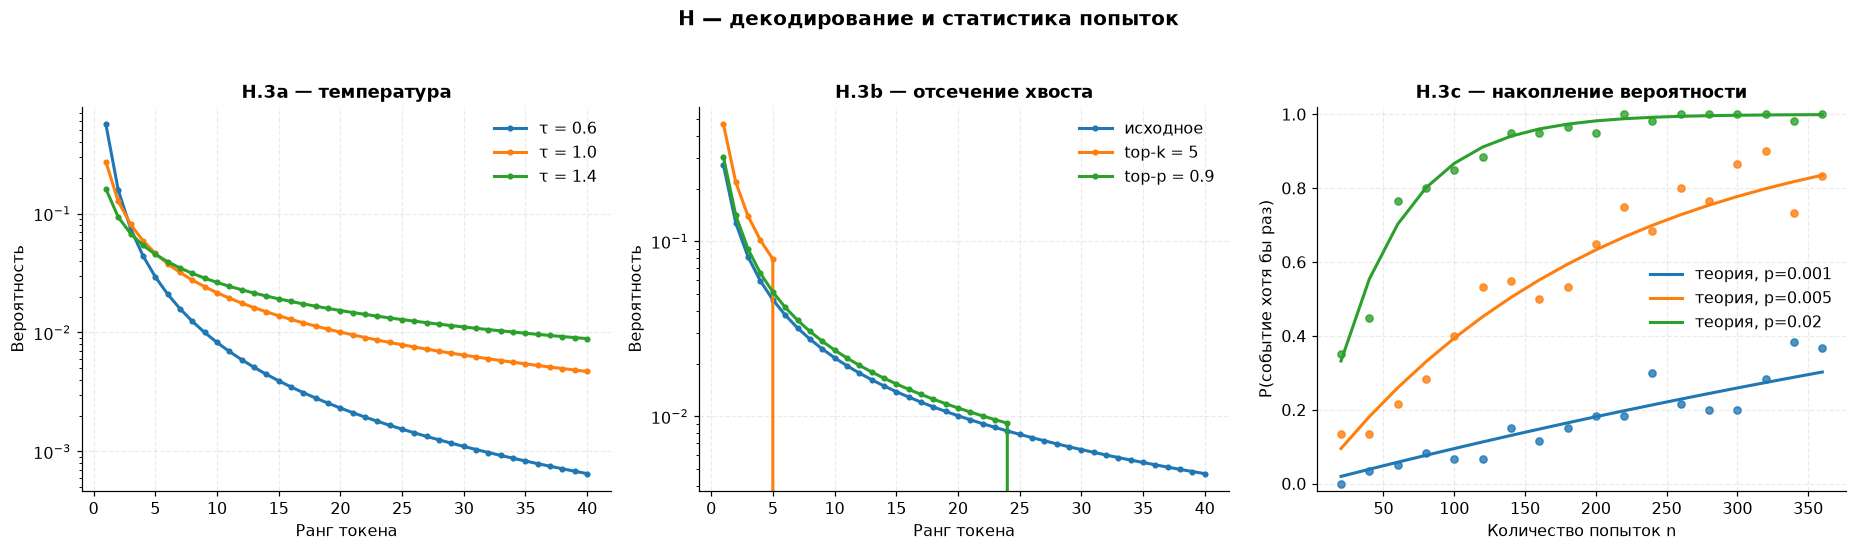

In [24]:
# H.3 — рисунок H из трёх панелей

fig = plt.figure(figsize=(17, 5))

# ------------------------------------------------------------
# Панель 1: распределения при разных температурах
# ------------------------------------------------------------

ax1 = plt.subplot(1, 3, 1)

for tau in TAUS:
    p_tau = softmax_t(logits, tau)

    ax1.plot(
        rank,
        p_tau,
        marker="o",
        markersize=3,
        linewidth=2,
        label=f"τ = {tau}"
    )

ax1.set_yscale("log")
ax1.set_xlabel("Ранг токена")
ax1.set_ylabel("Вероятность")
ax1.set_title("H.3a — температура")
ax1.legend()
ax1.grid(True, alpha=0.25, linestyle="--")


# ------------------------------------------------------------
# Панель 2: исходное распределение, top-k и top-p
# ------------------------------------------------------------

ax2 = plt.subplot(1, 3, 2)

p_base = softmax_t(logits, 1.0)
p_topk = top_k_filter(p_base, k=5)
p_topp = top_p_filter(p_base, thr=0.9)

ax2.plot(
    rank,
    p_base,
    marker="o",
    markersize=3,
    linewidth=2,
    label="исходное"
)

ax2.plot(
    rank,
    p_topk,
    marker="o",
    markersize=3,
    linewidth=2,
    label="top-k = 5"
)

ax2.plot(
    rank,
    p_topp,
    marker="o",
    markersize=3,
    linewidth=2,
    label="top-p = 0.9"
)

ax2.set_yscale("log")
ax2.set_xlabel("Ранг токена")
ax2.set_ylabel("Вероятность")
ax2.set_title("H.3b — отсечение хвоста")
ax2.legend()
ax2.grid(True, alpha=0.25, linestyle="--")


# ------------------------------------------------------------
# Панель 3: вероятность хотя бы одного события
# ------------------------------------------------------------

ax3 = plt.subplot(1, 3, 3)

for p_rare in P_RARES:
    theory = h2_results[p_rare]["theory"]
    measured = h2_results[p_rare]["measured"]

    # Теоретическая кривая
    ax3.plot(
        N_VALUES,
        theory,
        linewidth=2,
        label=f"теория, p={p_rare}"
    )

    # Измеренные точки
    ax3.scatter(
        N_VALUES,
        measured,
        s=22,
        alpha=0.8
    )

ax3.set_xlabel("Количество попыток n")
ax3.set_ylabel("P(событие хотя бы раз)")
ax3.set_title("H.3c — накопление вероятности")
ax3.set_ylim(-0.02, 1.02)
ax3.legend()
ax3.grid(True, alpha=0.25, linestyle="--")

finish(fig, "H — декодирование и статистика попыток")

In [25]:
# H.4 — расстояния ролей до точки генерации

TEMPLATE = [
    ("спец", 1),
    ("система", 7),
    ("спец", 1),
    ("пользователь", 5),
    ("спец", 1),
    ("документ", 4),
    ("инъекция", 6),
    ("спец", 1)
]

# Создаём список:
# для каждого токена записываем его роль.
roles = []

for role, count in TEMPLATE:
    roles.extend([role] * count)

T_total = len(roles)

# Точка генерации находится сразу после последнего токена.
generation_pos = T_total

# Для токена с индексом i расстояние до точки генерации:
# generation_pos - i
distances = np.arange(T_total, 0, -1)

print("Всего токенов:", T_total)
print("Позиция генерации:", generation_pos)

# Среднее расстояние для каждой роли.
role_distances = {}

for role, _ in TEMPLATE:
    role_distances[role] = distances[np.array(roles) == role].mean()

print("\nСреднее расстояние до точки генерации:")

for role, distance in role_distances.items():
    print(f"{role:12s}: {distance:.2f}")

Всего токенов: 26
Позиция генерации: 26

Среднее расстояние до точки генерации:
спец        : 14.25
система     : 22.00
пользователь: 15.00
документ    : 9.50
инъекция    : 4.50


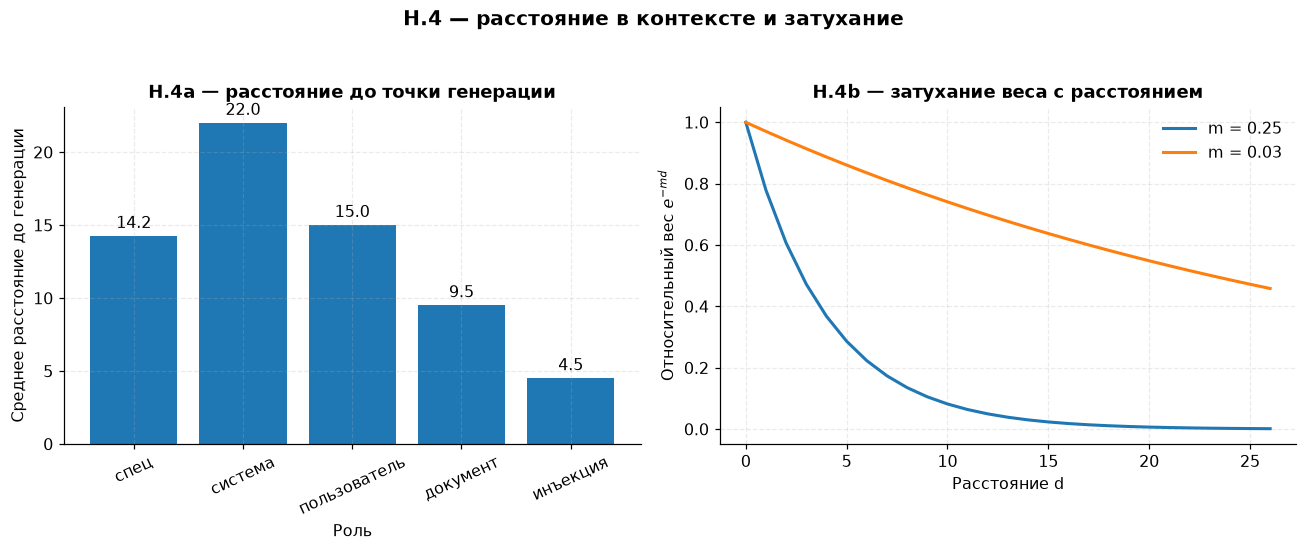

In [26]:
# H.4b — расстояния и относительный вес внимания

roles_unique = list(role_distances.keys())
mean_distances = np.array(
    [role_distances[r] for r in roles_unique]
)

fig = plt.figure(figsize=(12, 5))

# ------------------------------------------------------------
# Левая часть: среднее расстояние ролей
# ------------------------------------------------------------

ax1 = plt.subplot(1, 2, 1)

bars = ax1.bar(
    roles_unique,
    mean_distances
)

ax1.set_xlabel("Роль")
ax1.set_ylabel("Среднее расстояние до генерации")
ax1.set_title("H.4a — расстояние до точки генерации")

for bar, value in zip(bars, mean_distances):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

ax1.tick_params(axis="x", rotation=25)


# ------------------------------------------------------------
# Правая часть: exp(-m*d)
# ------------------------------------------------------------

ax2 = plt.subplot(1, 2, 2)

d = np.arange(0, T_total + 1)

for m in [0.25, 0.03]:
    weight = np.exp(-m * d)

    ax2.plot(
        d,
        weight,
        linewidth=2,
        label=f"m = {m}"
    )

ax2.set_xlabel("Расстояние d")
ax2.set_ylabel(r"Относительный вес $e^{-md}$")
ax2.set_title("H.4b — затухание веса с расстоянием")
ax2.legend()
ax2.grid(True, alpha=0.25, linestyle="--")

finish(fig, "H.4 — расстояние в контексте и затухание")

**Вопрос H.** Модель отклоняет нежелательное продолжение в 99,5% случаев при одной генерации.
Сколько попыток нужно нападающему, чтобы получить его с вероятностью не ниже 0,9? Какой вывод это
даёт для методики оценки устойчивости?

**Ответ H.** Нападающему достаточно четырех попыток

## Отчёт

### Таблица 1. Токенизация (часть A)

| Показатель | Значение |
|---|---|
| Число выполненных слияний | |
| Размер словаря токенов | |
| Сжатие «символы → BPE» | |
| Отношение «BPE → слова» | |
| Доля редких токенов (частота ≤ `RARE_THR`) | |

### Таблица 2. Затухание градиента (часть B)

| $\rho(W)$ или $f_t$ | Норма при $k=100$ | Горизонт до $10^{-6}$ |
|---|---|---|
| 0.9 | | |
| 1.0 | | |
| 1.2 | | |
| $f_t = 0.99$ | | |

### Таблица 3. Масштабирование внимания (часть C)

| $d_k$ | Энтропия с делителем | Энтропия без делителя |
|---|---|---|
| 8 | | |
| 64 | | |
| 256 | | |

### Таблица 4. Мини-трансформер (часть E)

| Число пар в контексте | 2 | 4 | 8 | 12 | 16 | 20 |
|---|---|---|---|---|---|---|
| Точность вспоминания | | | | | | |

Финальное значение функции потерь: ______  Время обучения: ______ с
Масса внимания финального запроса на позиции нужного значения: ______

### Таблица 5. Линейное внимание (часть F)

| Показатель | Значение |
|---|---|
| Расхождение параллельной и рекуррентной форм | |
| Размер состояния, чисел | |
| Качество чтения при 4 парах | |
| Качество чтения при 256 парах | |

### Таблица 6. Избирательная рекуррентность (часть G)

| Вариант ячейки | Точность | Комментарий |
|---|---|---|
| избирательные гейты | | |
| постоянное затухание | | |
| случайное угадывание | 0.062 | теоретическое значение |

Доля каналов с гейтом сохранения выше 0.9: ______

### Таблица 7. Декодирование (часть H)

| Температура варианта | Энтропия, нат | $p_{\max}$ |
|---|---|---|
| | | |
| | | |
| | | |

Число попыток для события с $p=0{,}005$ до вероятности 0,9: ______

### Выводы

Сформулируйте не менее пяти выводов. Каждый вывод должен опираться на конкретное измеренное число
из вашего прогона.

1.
2.
3.
4.
5.

## Контрольные вопросы

1. Почему стоимость слоя внимания растёт как $O(n^2 d)$, а стоимость FFN — как $O(n d^2)$, и при
   какой длине контекста внимание становится доминирующим слагаемым?
2. Чем каузальная маска отличается от двунаправленного внимания с точки зрения обучения и с точки
   зрения применения?
3. Почему RoPE позволяет расширять контекст после обучения, а обучаемая абсолютная кодировка — нет?
4. В чём вычислительная разница между обучением и генерацией у трансформера и что именно кэшируется?
5. Как GQA и MQA уменьшают KV-кэш и чем за это приходится платить?
6. Почему линейное внимание проигрывает softmax-вниманию на задачах точного вспоминания?
7. Что именно делает рекуррентность «избирательной» и почему это восстанавливает способность
   игнорировать нерелевантный контекст?
8. Почему смесь экспертов требует балансирующей потери и что происходит без неё?
9. Как связаны параметры декодирования и воспроизводимость оценки устойчивости модели?
10. Почему шаблон чата не создаёт настоящей границы привилегий между системной инструкцией и
    содержимым документа?

## Дополнительные задания

- Добавьте в часть E третий слой и проверьте, меняется ли характер переноса на длины больше
  обучающих.
- Замените в части E обучаемую абсолютную кодировку на RoPE и повторите измерение точности для
  16 и 20 пар.
- Реализуйте в части F многоголовое линейное внимание и постройте зависимость качества чтения от
  числа голов при фиксированном общем размере состояния.
- Реализуйте слой смеси экспертов с балансирующей потерей и покажите, как меняется распределение
  нагрузки при её отключении.
- Постройте в части H оценку числа попыток до заданной вероятности успеха как функцию $p$ и
  обсудите, как это влияет на протокол тестирования.

## Чек-лист сдачи

- [ ] Заполнен паспорт работы, указан вариант и его параметры.
- [ ] Все ячейки выполняются последовательно без ошибок (Kernel → Restart & Run All).
- [ ] Реализованы все `TODO` в частях A–H.
- [ ] Заполнены таблицы 1–7 числами своего варианта.
- [ ] Даны ответы на вопросы A–H и контрольные вопросы 1–10.
- [ ] Сформулировано не менее пяти выводов со ссылками на измеренные значения.
- [ ] Все графики подписаны по-русски и читаемы.



## Литература

- Vaswani A. et al. Attention Is All You Need (2017): <https://arxiv.org/abs/1706.03762>
- Hochreiter S., Schmidhuber J. Long Short-Term Memory (1997):
  <https://direct.mit.edu/neco/article/9/8/1735/6109>
- Su J. et al. RoFormer: Enhanced Transformer with Rotary Position Embedding (2021):
  <https://arxiv.org/abs/2104.09864>
- Press O. et al. Train Short, Test Long: Attention with Linear Biases (ALiBi) (2021):
  <https://arxiv.org/abs/2108.12409>
- Katharopoulos A. et al. Transformers are RNNs: Fast Autoregressive Transformers with Linear
  Attention (2020): <https://arxiv.org/abs/2006.16236>
- Gu A., Dao T. Mamba: Linear-Time Sequence Modeling with Selective State Spaces (2023):
  <https://arxiv.org/abs/2312.00752>
- Ainslie J. et al. GQA: Training Generalized Multi-Query Transformer Checkpoints (2023):
  <https://arxiv.org/abs/2305.13245>
- Dao T. et al. FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness (2022):
  <https://arxiv.org/abs/2205.14135>
- Olsson C. et al. In-context Learning and Induction Heads (2022):
  <https://arxiv.org/abs/2209.11895>
- Holtzman A. et al. The Curious Case of Neural Text Degeneration (2019):
  <https://arxiv.org/abs/1904.09751>